# Bowel Sound Data Analysis — exp00
## Comprehensive EDA + Acoustic Analysis (Both Datasets)

This is the **single reference notebook** for all data understanding.
It covers both recordings throughout every section so comparisons are always direct.

| Recording | Duration | Bowel events | Events/min |
|-----------|----------|--------------|------------|
| 23M74M    | ~5 min   | 514          | ~103       |
| AS_1      | ~37 min  | 1712         | ~46        |

### Contents
1. Setup & Paths
2. Raw Annotation Audit
3. Label Cleaning
4. Per-Class Duration Statistics
5. Duration Distribution Plots
6. Timeline & Density Analysis
7. Audio Signal Statistics per Class
8. Mel Spectrograms — Representative Events (per dataset)
9. Mean Mel Spectrum per Class (per dataset)
10. Spectral Centroid Distribution (per dataset)
11. Listen — Audio Clips per Class
12. Cross-Dataset Acoustic Comparison
13. Observations & Conclusions

## 1 · Setup & Paths

In [ ]:
import warnings, random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.io.wavfile as wavfile
from pathlib import Path
from scipy import stats as sp_stats
from IPython.display import Audio, display as ipy_display
import IPython.display as ipd

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

try:
    import google.colab
    COLAB = True
    REPO_DIR = Path('/content/bowel-sound')
    if not REPO_DIR.exists():
        import os
        os.system(f'git clone  https://github.com/medmabcf/bowel-sound.git {REPO_DIR}')
    DATA_DIR = REPO_DIR / 'bowel-data'
    OUT_DIR  = REPO_DIR
except ImportError:
    COLAB = False
    DATA_DIR = Path('bowel-data')
    OUT_DIR  = Path('.')

FILES = {
    '23M74M': {'wav': DATA_DIR / '23M74M.wav', 'txt': DATA_DIR / '23M74M.txt'},
    'AS_1':   {'wav': DATA_DIR / 'AS_1.wav',   'txt': DATA_DIR / 'AS_1.txt'},
}

# Analysis sample rate — high quality for display
SR = 22050

# Mel spectrogram params
N_MELS     = 64
N_FFT      = 1024
HOP_LENGTH = 128
FMAX       = 4000
VIZ_PAD    = 0.05   # 50 ms padding for spectrogram displays
LISTEN_PAD = 0.10   # 100 ms padding for audio clips

ALIAS_MAP     = {'sbs': 'sb', 'b': 'sb', 'SB': 'sb', 'mbs': 'mb', 'MB': 'mb',
                 'H': 'h', 'harmonic': 'h'}
KEEP_LABELS   = {'sb', 'mb', 'h'}
IGNORE_LABELS = {'n', 'v'}
ALL_LABELS    = ['sb', 'mb', 'h']

CLASS_COLORS  = {'sb': '#2196F3', 'mb': '#FF5722', 'h': '#4CAF50'}
CLASS_NAMES   = {'sb': 'Single Burst', 'mb': 'Multiple Burst', 'h': 'Harmonic'}
REC_COLORS    = {'23M74M': '#1565C0', 'AS_1': '#BF360C'}
REC_MARKERS   = {'23M74M': 'o', 'AS_1': 's'}

AUDIO_OUT = OUT_DIR / 'audio_clips'
AUDIO_OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

print(f'Environment: {"Colab" if COLAB else "Local"}')
print(f'Data dir:    {DATA_DIR}')
for name, f in FILES.items():
    wav_ok = f['wav'].exists()
    txt_ok = f['txt'].exists()
    print(f'  {name}: wav={wav_ok}  txt={txt_ok}')

Environment: Local
Data dir:    bowel-data
  23M74M: wav=True  txt=True
  AS_1: wav=True  txt=True


## 2 · Raw Annotation Audit

Load both `.txt` files **exactly as-is** — zero modifications. Goal: surface every label variant, whitespace issue, and anomaly before fixing anything.

In [2]:
def load_raw(txt_path, name):
    df = pd.read_csv(txt_path, sep='\t', header=None, names=['start', 'end', 'label'])
    df['label_raw'] = df['label']
    df['duration']  = df['end'] - df['start']
    df['recording'] = name
    return df

raw = {name: load_raw(f['txt'], name) for name, f in FILES.items()}

print('=' * 65)
print('RAW ANNOTATION AUDIT  (no changes applied)')
print('=' * 65)
for name, df in raw.items():
    dur_audio = librosa.get_duration(path=str(FILES[name]['wav']))
    print(f'\n──── {name} ────────────────────────────────────────────')
    print(f'  Audio duration    : {dur_audio:.1f} s  ({dur_audio/60:.1f} min)')
    print(f'  Annotation rows   : {len(df)}')
    print(f'  Recording span    : {df["start"].min():.3f} → {df["end"].max():.3f} s')
    print(f'  Every unique label found (repr shows whitespace):')
    for lbl, cnt in df['label_raw'].value_counts().items():
        flag = '  ← WHITESPACE' if lbl != lbl.strip() else (
               '  ← NON-STANDARD' if lbl not in {'sb','mb','h','n','v','b','sbs'} else '')
        print(f'    {repr(lbl):12s}  count={cnt:5d}  ({100*cnt/len(df):5.1f}%){flag}')

print('\n' + '=' * 65)
print('CROSS-FILE LABEL MATRIX (raw)')
all_raw = pd.concat(raw.values(), ignore_index=True)
print(all_raw.groupby(['recording', 'label_raw']).size().unstack(fill_value=0))

RAW ANNOTATION AUDIT  (no changes applied)

──── 23M74M ────────────────────────────────────────────
  Audio duration    : 300.6 s  (5.0 min)
  Annotation rows   : 522
  Recording span    : 1.125 → 299.819 s
  Every unique label found (repr shows whitespace):
    'sb'          count=  254  ( 48.7%)
    'mb'          count=  230  ( 44.1%)
    'h'           count=   29  (  5.6%)
    'n'           count=    8  (  1.5%)
    'sbs'         count=    1  (  0.2%)

──── AS_1 ────────────────────────────────────────────
  Audio duration    : 2212.4 s  (36.9 min)
  Annotation rows   : 1927
  Recording span    : 0.000 → 2517.790 s
  Every unique label found (repr shows whitespace):
    'b'           count=  857  ( 44.5%)
    'mb'          count=  773  ( 40.1%)
    'v'           count=  117  (  6.1%)
    'n'           count=   97  (  5.0%)
    'h'           count=   80  (  4.2%)
    'mb '         count=    1  (  0.1%)  ← WHITESPACE
    ' b'          count=    1  (  0.1%)  ← WHITESPACE
    ' v'     

### Conclusions — Raw Audit

**23M74M (5.0 min, 522 rows):** Uses `sb` consistently — except 1 typo `sbs` (0.2%). Only 5 distinct labels: `sb`, `mb`, `h`, `n`, and the `sbs` typo. Very clean.

**AS_1 (36.9 min, 1927 rows):** Uses `b` (not `sb`) for single burst — 857 rows (44.5%). Has 3 whitespace-corrupted labels: `'mb '`, `' b'`, `' v'`. Contains 118 `v` (voice) labels to exclude. Annotation span is longer than audio — tail annotations can be safely ignored.

**Action:** Strip whitespace → apply alias map `{'b': 'sb', 'sbs': 'sb'}`.

## 3 · Label Cleaning

In [3]:
def load_and_clean(txt_path, name):
    df = load_raw(txt_path, name)
    df['label'] = df['label_raw'].str.strip()
    df['label'] = df['label'].replace(ALIAS_MAP)
    df['duration'] = df['end'] - df['start']
    return df

clean    = {name: load_and_clean(f['txt'], name) for name, f in FILES.items()}
all_df   = pd.concat(clean.values(), ignore_index=True)
bowel_df = all_df[all_df['label'].isin(KEEP_LABELS)].copy().reset_index(drop=True)

print('=' * 65)
print('AFTER CLEANING')
print('=' * 65)
for name, df in clean.items():
    print(f'\n──── {name}')
    for lbl, cnt in df['label'].value_counts().items():
        flag = '  ← UNEXPECTED' if lbl not in KEEP_LABELS | IGNORE_LABELS else ''
        print(f'    {repr(lbl):12s}  count={cnt:5d}{flag}')

print('\nFinal bowel-sound event counts (n and v excluded):')
pivot = bowel_df.groupby(['recording', 'label']).size().unstack(fill_value=0)
pivot['TOTAL'] = pivot.sum(axis=1)
print(pivot)
print(f'\nGrand total bowel events: {len(bowel_df)}')

AFTER CLEANING

──── 23M74M
    'sb'          count=  255
    'mb'          count=  230
    'h'           count=   29
    'n'           count=    8

──── AS_1
    'sb'          count=  858
    'mb'          count=  774
    'v'           count=  118
    'n'           count=   97
    'h'           count=   80

Final bowel-sound event counts (n and v excluded):
label       h   mb   sb  TOTAL
recording                     
23M74M     29  230  255    514
AS_1       80  774  858   1712

Grand total bowel events: 2226


### Conclusions — Label Cleaning

| Recording | h  | mb  | sb  | Total  |
|-----------|----|-----|-----|--------|
| 23M74M    | 29 | 230 | 255 | **514** |
| AS_1      | 80 | 774 | 858 | **1712** |
| **Combined** | **109** | **1004** | **1113** | **2226** |

`sb` is dominant (50%), `mb` close second (45%), `h` rare (5% — class imbalance challenge). AS_1 contributes 77% of data.

## 4 · Per-Class Duration Statistics

Duration is the most critical property for deciding window size, IoU threshold, and SMOOTH_WIN per class.

In [4]:
import numpy as np
import pandas as pd
import scipy.stats as sp_stats

pct_labels = [5, 10, 25, 50, 75, 90, 95]

# Get the unique recordings in the dataset
recordings = bowel_df['recording'].unique()

for rec in recordings:
    # Filter the dataframe for the current recording
    rec_df = bowel_df[bowel_df['recording'] == rec]
    
    print('=' * 80)
    print(f'PER-CLASS DURATION STATISTICS FOR: {rec}  ({len(rec_df)} total events)')
    print('=' * 80)

    for lbl in ['sb', 'mb', 'h']:
        sub = rec_df[rec_df['label'] == lbl]['duration']
        
        # Skip if a class happens to have no events in this recording
        if len(sub) == 0:
            continue
            
        print(f'\n  CLASS: {lbl.upper()}  ({len(sub)} events)')
        print(f'  {"─"*60}')
        print(f'  Min          : {sub.min():.4f} s')
        print(f'  Max          : {sub.max():.4f} s')
        print(f'  Range        : {sub.max() - sub.min():.4f} s')
        print(f'  Mean         : {sub.mean():.4f} s')
        print(f'  Median (p50) : {sub.median():.4f} s')
        print(f'  Std dev      : {sub.std():.4f} s')
        print(f'  Skewness     : {sp_stats.skew(sub):.3f}')
        print(f'  Percentiles  :')
        
        for p in pct_labels:
            val = np.percentile(sub, p)
            # Calculate text bar length (max out at 30 characters relative to the max value)
            bar_len = int((val / sub.max()) * 30) if sub.max() > 0 else 0
            print(f'    p{p:2d}: {val:.4f} s  {"█" * bar_len}')

    print(f'\n  COMPACT COMPARISON TABLE: {rec}')
    print('  ' + '-' * 70)
    
    stats_rows = []
    for lbl in ['sb', 'mb', 'h']:
        sub = rec_df[rec_df['label'] == lbl]['duration']
        if len(sub) == 0:
            continue
        stats_rows.append({
            'class': lbl, 'count': len(sub),
            'min': sub.min(), 'p5': np.percentile(sub, 5), 'p25': np.percentile(sub, 25),
            'median': sub.median(), 'mean': sub.mean(), 'p75': np.percentile(sub, 75),
            'p95': np.percentile(sub, 95), 'max': sub.max(), 'std': sub.std()
        })
        
    stats_df = pd.DataFrame(stats_rows).set_index('class')
    print('  ' + stats_df.round(4).to_string().replace('\n', '\n  '))
    print('\n\n')

PER-CLASS DURATION STATISTICS FOR: 23M74M  (514 total events)

  CLASS: SB  (255 events)
  ────────────────────────────────────────────────────────────
  Min          : 0.0376 s
  Max          : 0.1342 s
  Range        : 0.0966 s
  Mean         : 0.0721 s
  Median (p50) : 0.0698 s
  Std dev      : 0.0149 s
  Skewness     : 0.826
  Percentiles  :
    p 5: 0.0502 s  ███████████
    p10: 0.0537 s  ████████████
    p25: 0.0617 s  █████████████
    p50: 0.0698 s  ███████████████
    p75: 0.0805 s  █████████████████
    p90: 0.0912 s  ████████████████████
    p95: 0.0966 s  █████████████████████

  CLASS: MB  (230 events)
  ────────────────────────────────────────────────────────────
  Min          : 0.0805 s
  Max          : 4.0338 s
  Range        : 3.9533 s
  Mean         : 0.3687 s
  Median (p50) : 0.2389 s
  Std dev      : 0.4298 s
  Skewness     : 4.297
  Percentiles  :
    p 5: 0.1047 s  
    p10: 0.1178 s  
    p25: 0.1396 s  █
    p50: 0.2389 s  █
    p75: 0.3972 s  ██
    p90: 0.78

### 📋 Conclusions — Duration Statistics

**SB — Single Burst (1113 events): "The Brief, Consistent Spikes"**

With a median of **0.126 s** and a tiny std dev of **0.037 s**, `sb` events are extremely compact and consistent. 95% of them are under **0.178 s**. The skewness of 1.16 confirms a slight right tail (a few longer ones), but the distribution is narrow. Importantly, AS_1's `sb` events (median 0.131 s) are nearly **twice as long** as 23M74M's (median 0.070 s) — these are physically different patients and may represent different intestinal motion speeds.


---

**MB — Multiple Burst (1004 events): "The Variable Clusters"**

With a median of **0.349 s** but a max of **4.034 s** and skewness of 3.14, `mb` has a long right tail. 

---

**H — Harmonic (109 events): "The Rare, Sustained Tones"**

At a median of **0.551 s** and max of **3.315 s**, harmonics are, on average, the longest bowel sounds sustained resonances. However, with only **109 events total (5% of the data)**, this class is severely imbalanced. 

**SMOOTH_WIN impact:** At 20ms frames, SMOOTH_WIN=5 (100ms window) kills sb p10 (70ms). Recommended per-class: `sb=3, mb=5, h=7`.

## 5 · Duration Distribution Plots

Histograms split by recording reveal the patient-level variability.

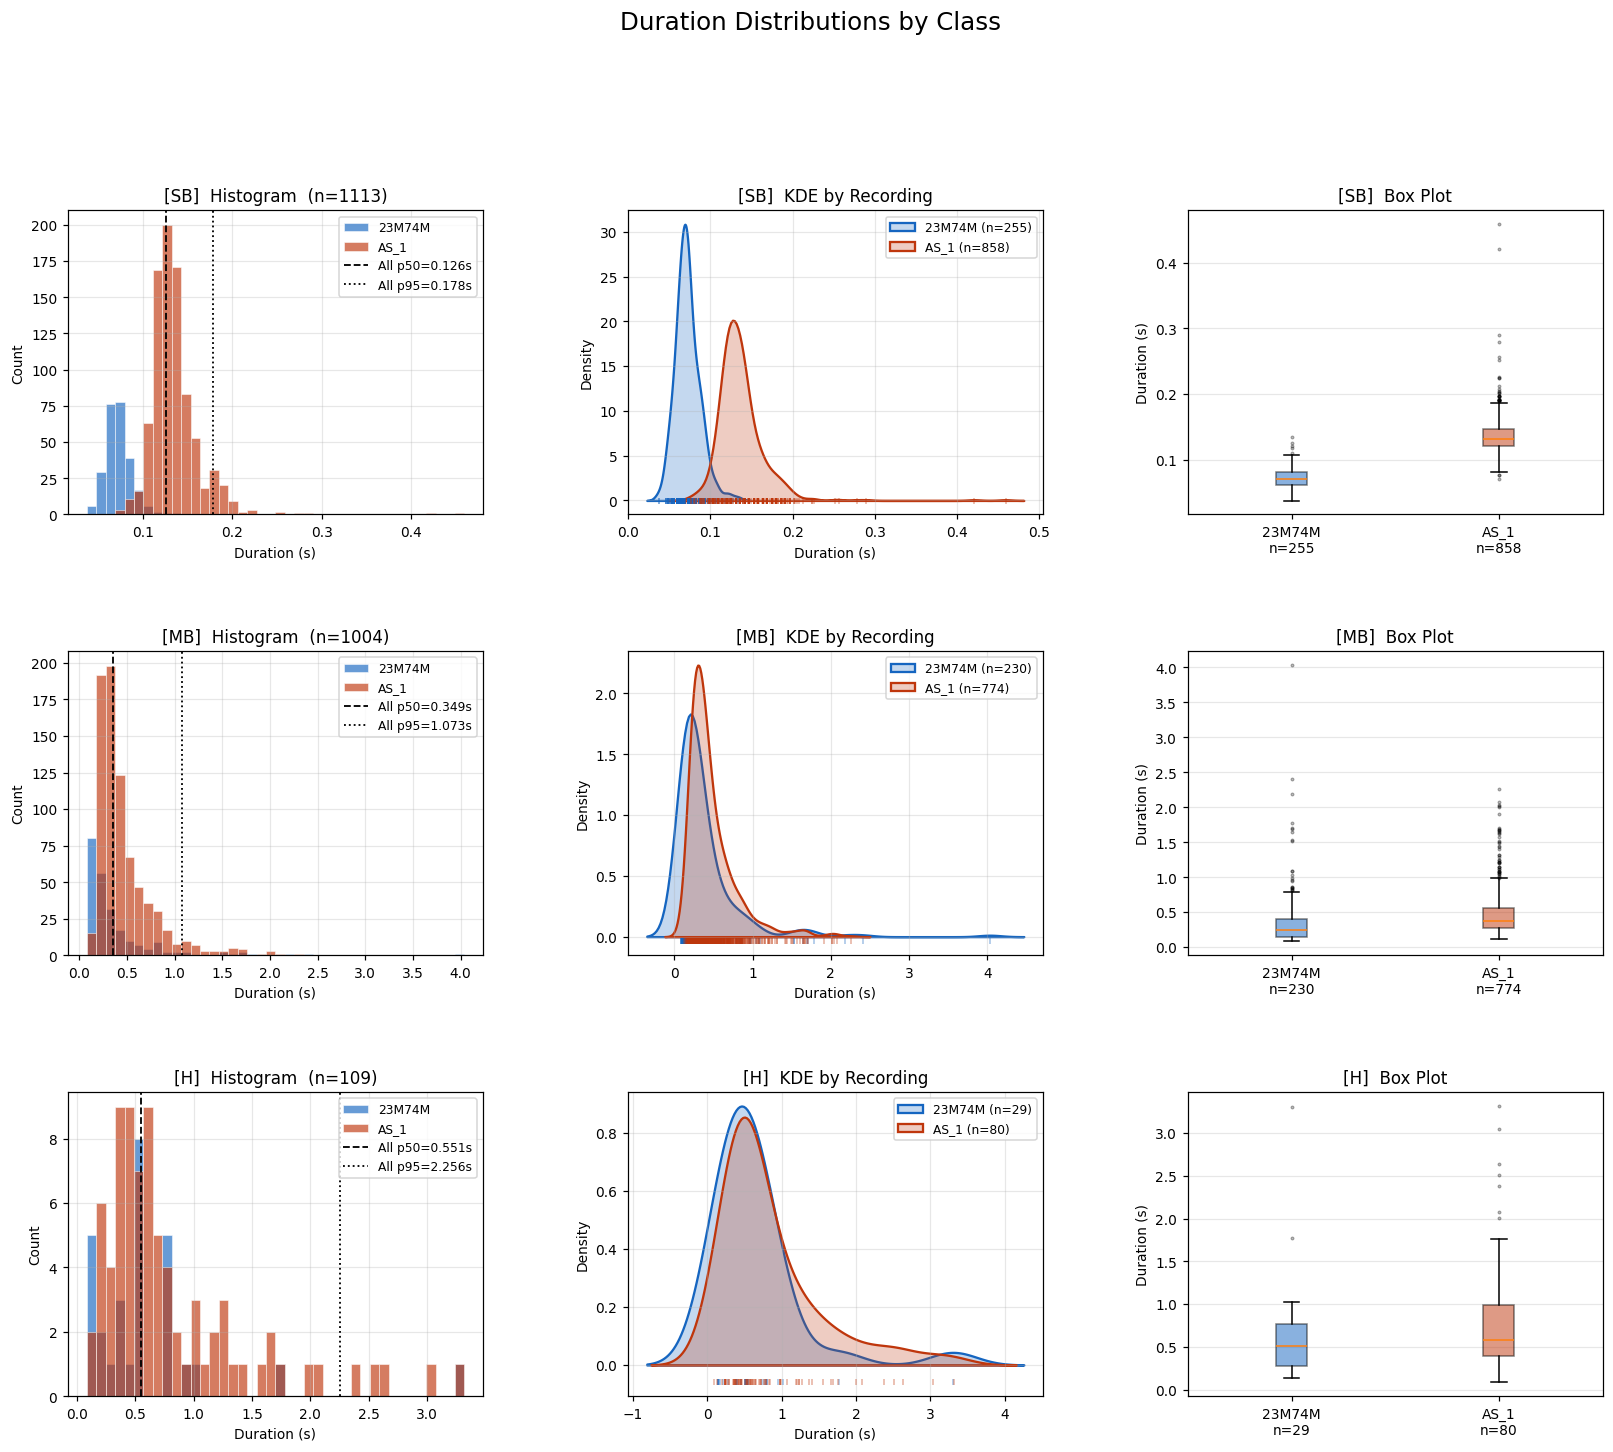

Figure saved to duration_distributions.png


In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Duration Distributions by Class', fontsize=16, y=1.01)

for row_i, lbl in enumerate(['sb', 'mb', 'h']):
    sub_all = bowel_df[bowel_df['label'] == lbl]['duration']
    sub_23  = bowel_df[(bowel_df['label']==lbl)&(bowel_df['recording']=='23M74M')]['duration']
    sub_as  = bowel_df[(bowel_df['label']==lbl)&(bowel_df['recording']=='AS_1')]['duration']
    
    # --- HISTOGRAM (ax0) ---
    ax0 = fig.add_subplot(gs[row_i, 0])
    
    # Generate shared bins so the bars for both patients line up exactly
    shared_bins = np.histogram_bin_edges(sub_all, bins=40)
    
    # Plot 23M74M separately
    ax0.hist(
        sub_23, 
        bins=shared_bins, 
        color=REC_COLORS['23M74M'], 
        label='23M74M',
        alpha=0.65,          # Transparency allows you to see the overlap
        edgecolor='white', 
        linewidth=0.5
    )
    
    # Plot AS_1 separately
    ax0.hist(
        sub_as, 
        bins=shared_bins, 
        color=REC_COLORS['AS_1'], 
        label='AS_1',
        alpha=0.65,          # Transparency allows you to see the overlap
        edgecolor='white', 
        linewidth=0.5
    )
    
    for p, ls in [(50,'--'),(95,':')]:
        v = np.percentile(sub_all, p)
        ax0.axvline(v, color='black', linestyle=ls, linewidth=1.2, label=f'All p{p}={v:.3f}s')
        
    ax0.set_title(f'[{lbl.upper()}]  Histogram  (n={len(sub_all)})', fontsize=11)
    ax0.set_xlabel('Duration (s)')
    ax0.set_ylabel('Count')
    ax0.legend(fontsize=8)
    ax0.grid(alpha=0.3)

    # --- KDE PLOT (ax1) ---
    ax1 = fig.add_subplot(gs[row_i, 1])
    for sub, name, c in [(sub_23,'23M74M',REC_COLORS['23M74M']),(sub_as,'AS_1',REC_COLORS['AS_1'])]:
        if len(sub) > 1:
            sns.kdeplot(sub, ax=ax1, color=c, label=f'{name} (n={len(sub)})',
                        fill=True, alpha=0.25, linewidth=1.5)
            ax1.plot(sub, np.full(len(sub), -0.02*(row_i+1)), '|', color=c, alpha=0.4, markersize=4)
    ax1.set_title(f'[{lbl.upper()}]  KDE by Recording', fontsize=11)
    ax1.set_xlabel('Duration (s)')
    ax1.set_ylabel('Density')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    # --- BOX PLOT (ax2) ---
    ax2 = fig.add_subplot(gs[row_i, 2])
    bp = ax2.boxplot([sub_23.values, sub_as.values],
                      labels=[f'23M74M\nn={len(sub_23)}', f'AS_1\nn={len(sub_as)}'],
                      patch_artist=True, showfliers=True,
                      flierprops=dict(marker='.', markersize=3, alpha=0.4))
    for patch, c in zip(bp['boxes'], [REC_COLORS['23M74M'], REC_COLORS['AS_1']]):
        patch.set_facecolor(c)
        patch.set_alpha(0.5)
    ax2.set_title(f'[{lbl.upper()}]  Box Plot', fontsize=11)
    ax2.set_ylabel('Duration (s)')
    ax2.grid(alpha=0.3, axis='y')

plt.savefig(DATA_DIR / 'duration_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to duration_distributions.png')

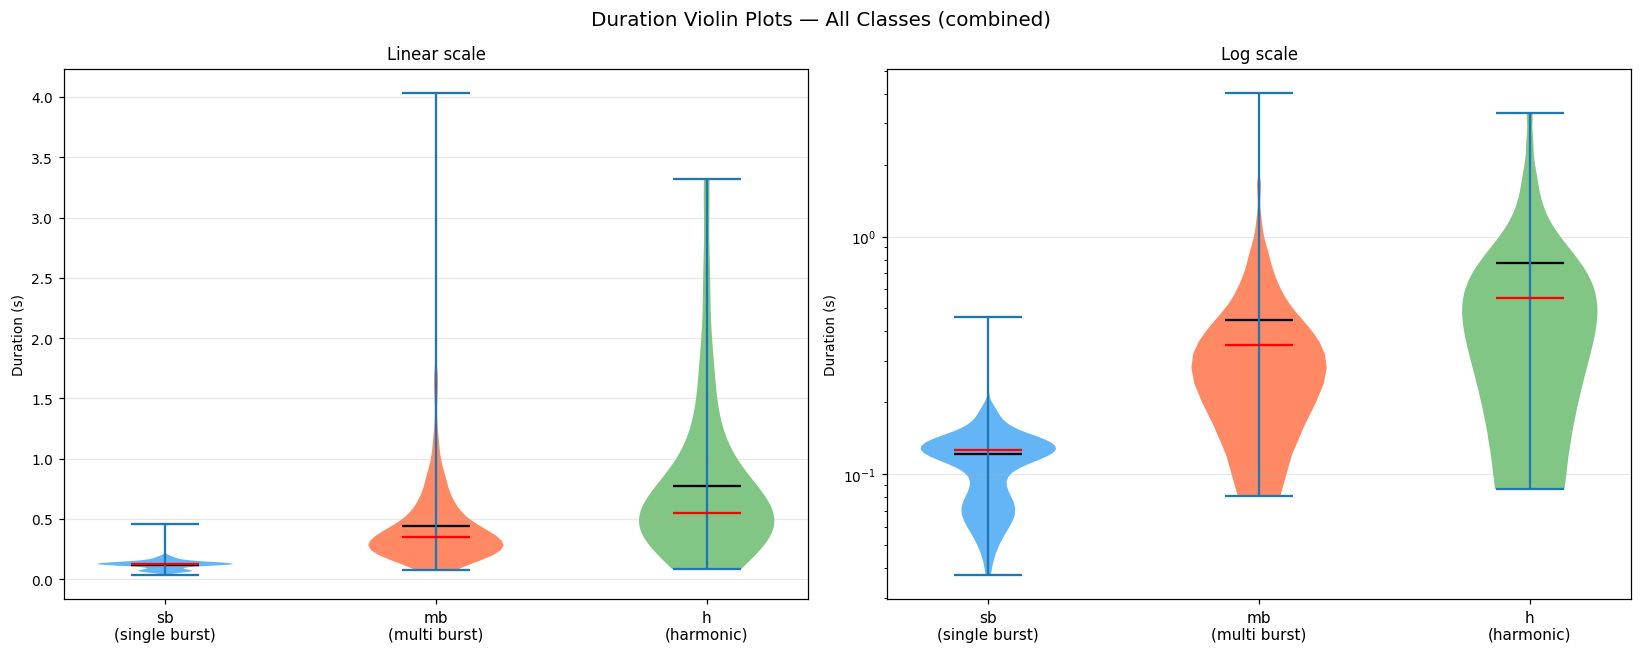

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Duration Violin Plots — All Classes (combined)', fontsize=13)

for ax, log_scale, title_sfx in zip(axes, [False, True], ['Linear scale', 'Log scale']):
    data  = [bowel_df[bowel_df['label']==l]['duration'].values for l in ALL_LABELS]
    parts = ax.violinplot(data, positions=[1,2,3], showmeans=True, showmedians=True, showextrema=True)
    for pc, lbl in zip(parts['bodies'], ALL_LABELS):
        pc.set_facecolor(CLASS_COLORS[lbl]); pc.set_alpha(0.7)
    parts['cmeans'].set_color('black'); parts['cmedians'].set_color('red')
    ax.set_xticks([1,2,3])
    ax.set_xticklabels(['sb\n(single burst)','mb\n(multi burst)','h\n(harmonic)'], fontsize=10)
    ax.set_ylabel('Duration (s)'); ax.set_title(title_sfx); ax.grid(alpha=0.3, axis='y')
    if log_scale: ax.set_yscale('log')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_duration_violin.png'), dpi=120, bbox_inches='tight')
plt.show()

### 📋 Conclusions — Duration Distributions

**SB histogram:** A **bimodal mixture distribution**. The overlapping histograms and KDE plots perfectly illustrate that the overall dataset consists of two entirely distinct patient signatures. 23M74M's `sb` events are tightly clustered around a peak of **0.070 s**, while AS_1's peak around **0.131 s** — almost a factor of 2 difference. This indicates that "single burst" lengths are highly patient-dependent.

**MB histogram:** Highly right-skewed (skewness = 3.14). Both recordings show the bulk of events clustering tightly between 0.15–0.60 s (median 0.349 s). However, there is a heavy right tail extending all the way out to 4.0 s. These outliers represent extended, continuous bubbling sequences, demonstrating that while most `mb` events are brief, their maximum duration is highly volatile.

**H histogram:** Also right-skewed (skewness = 2.05), with the widest relative spread. The box plots and KDE distributions show that `h` events span a much larger baseline duration range than `sb`. Harmonics represent the longest sustained sounds on average (median 0.551 s), with outliers stretching past 3.0 s, yet the vast majority of these tonal events still naturally resolve in under 1 second. 

**Cross-recording difference (box plots):** For `mb` and `h`, the two recordings share very similar median durations and interquartile ranges, showing consistency in how these events manifest across subjects. Conversely, for `sb`, the box for AS_1 sits entirely above and is noticeably wider than 23M74M. This stark contrast confirms fundamentally different physiological bowel speeds or acoustic profiles. This heavily reinforces the need for a **file-based (or patient-level) train/test split** rather than a pooled random split, ensuring any model learns to generalize across differing subjects.

## 6 · Timeline & Density Analysis

How events are distributed across each recording — gaps, clusters, quiet periods.

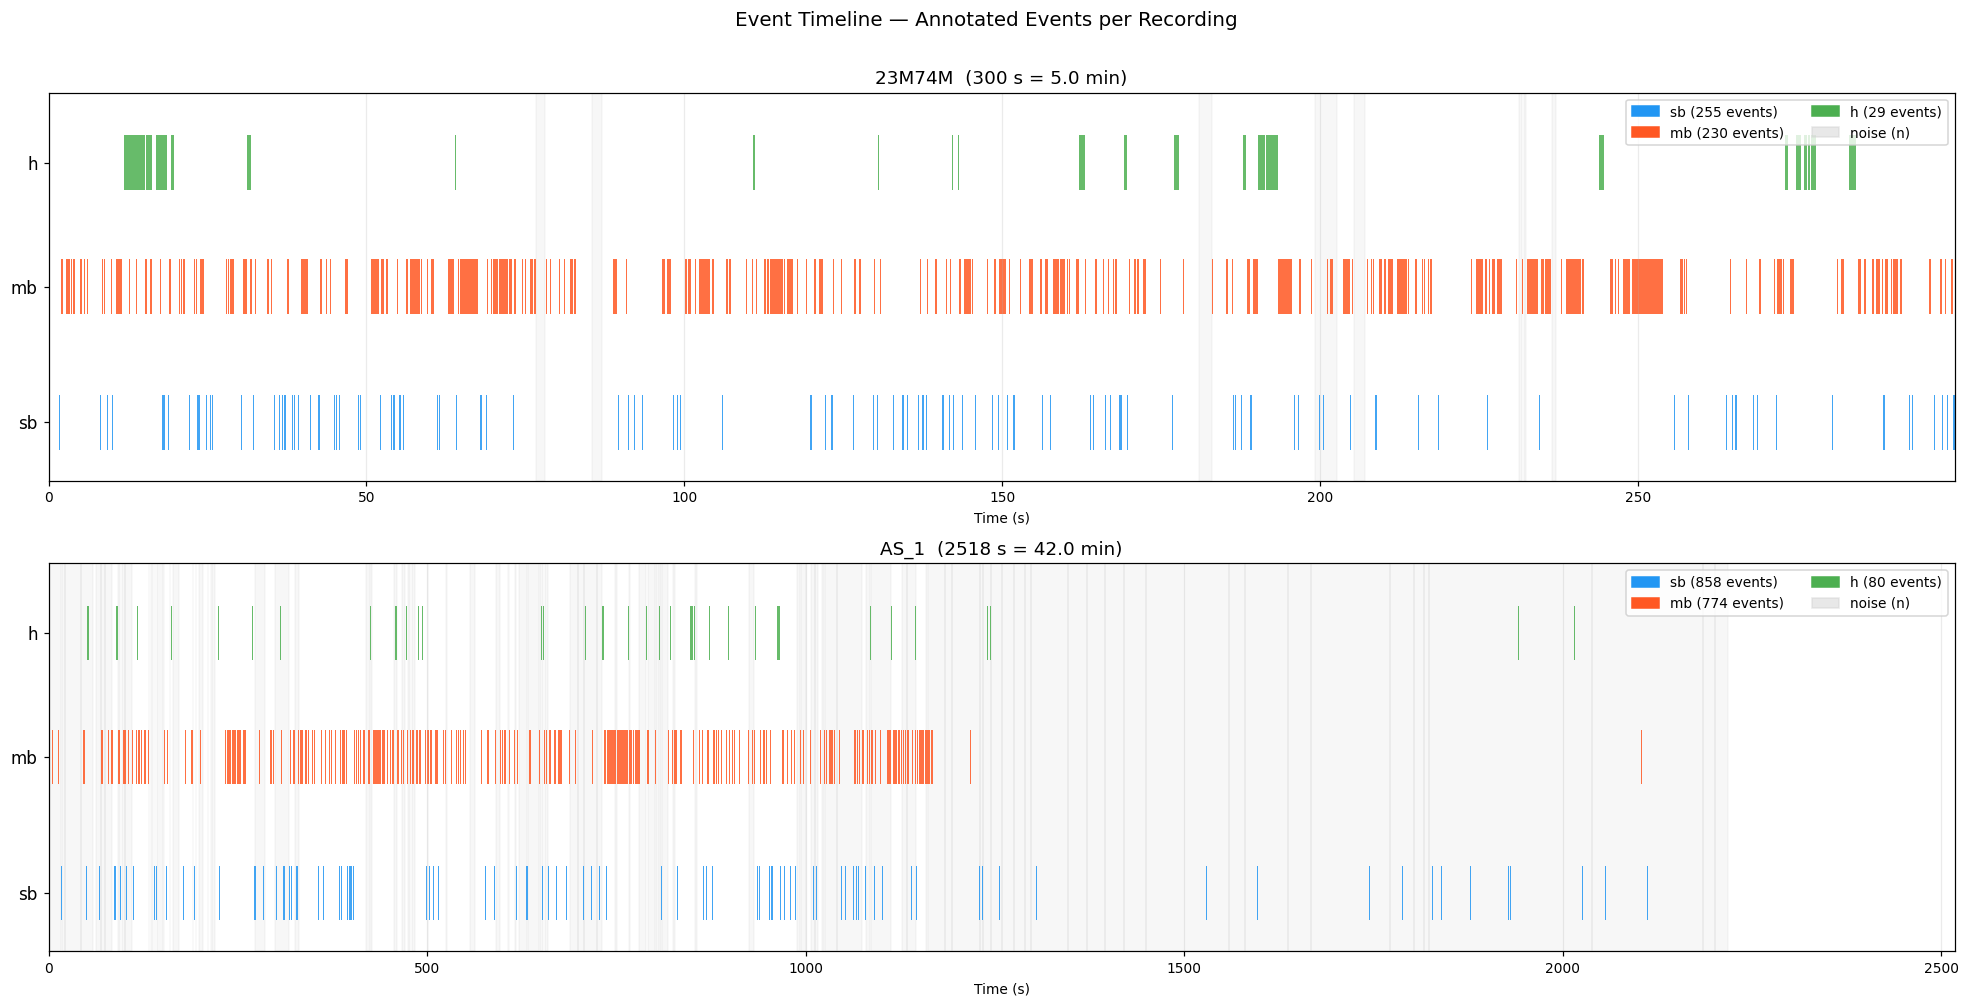

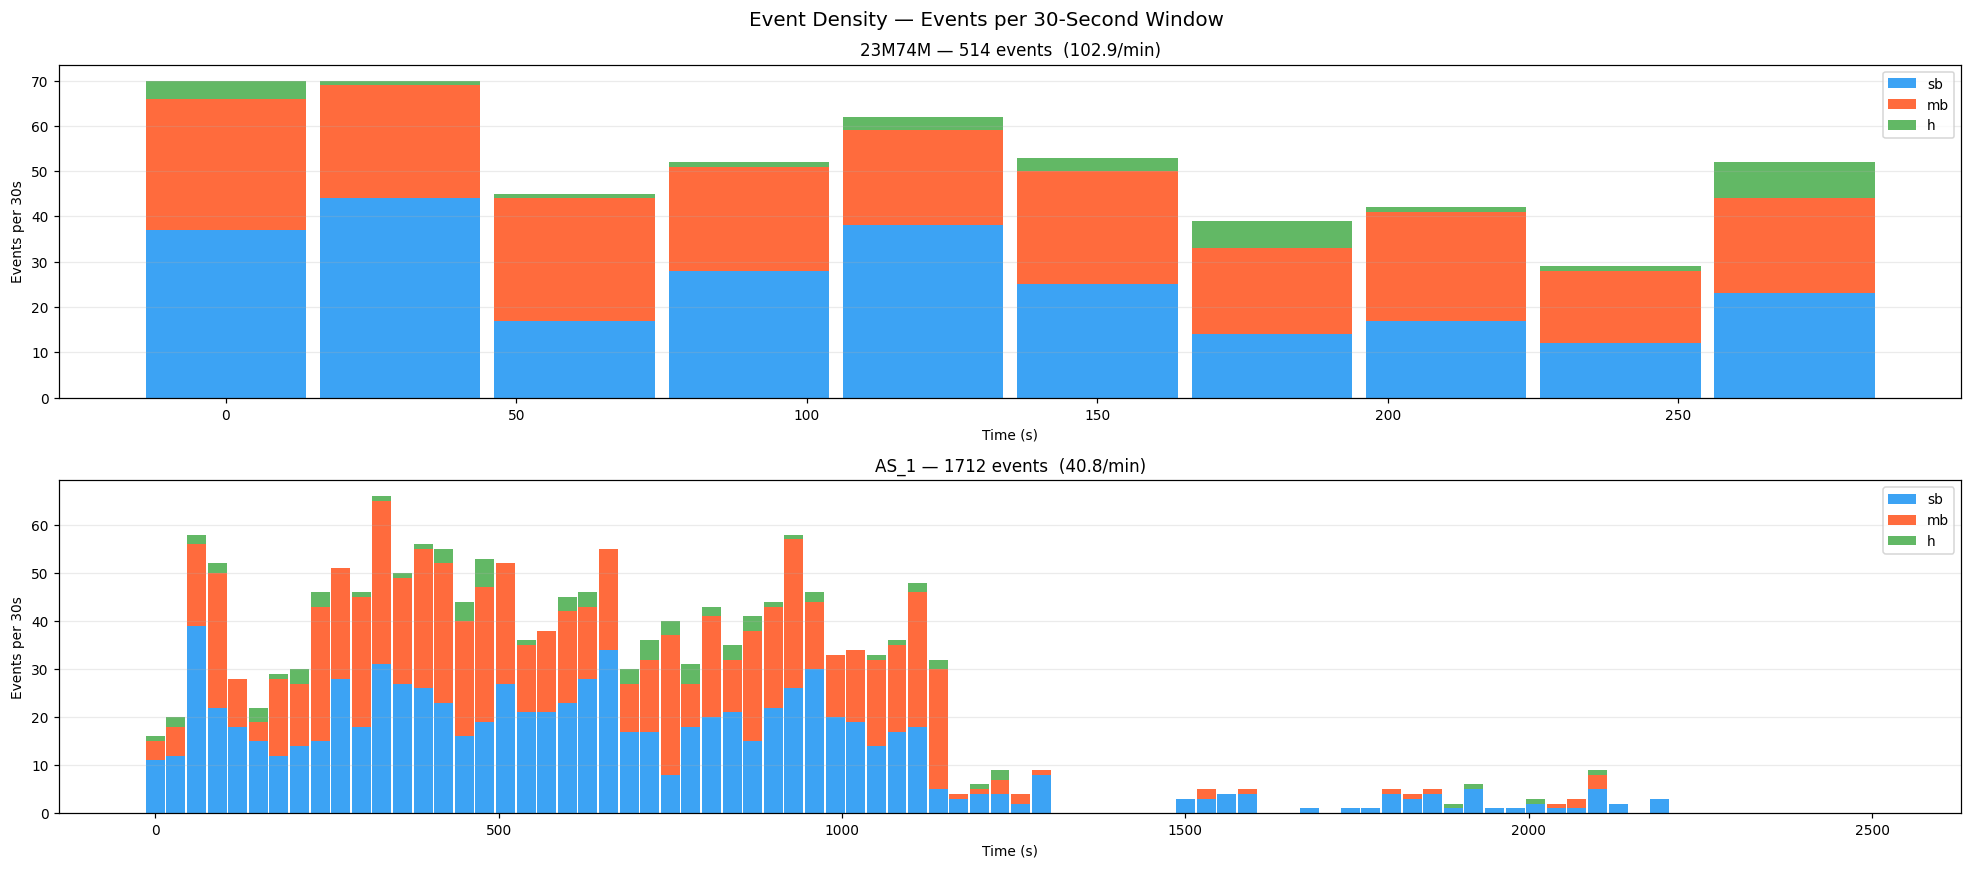

In [7]:
Y_POS = {'sb': 0.15, 'mb': 0.50, 'h': 0.82}
HEIGHT = 0.14

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=False)
fig.suptitle('Event Timeline — Annotated Events per Recording', fontsize=13, y=1.01)

for ax, (name, df) in zip(axes, clean.items()):
    max_t = df['end'].max()
    ax.set_xlim(0, max_t); ax.set_ylim(0, 1.0)
    for _, row in df[df['label']=='n'].iterrows():
        ax.axvspan(row['start'], row['end'], alpha=0.06, color='gray')
    for lbl in ALL_LABELS:
        for _, row in df[df['label']==lbl].iterrows():
            ax.broken_barh([(row['start'], max(row['duration'], 0.08))],
                            (Y_POS[lbl]-HEIGHT/2, HEIGHT),
                            facecolors=CLASS_COLORS[lbl], edgecolors='none', alpha=0.85)
    patches = [mpatches.Patch(color=CLASS_COLORS[l],
                label=f"{l} ({len(df[df['label']==l])} events)") for l in ALL_LABELS]
    patches.append(mpatches.Patch(color='lightgray', alpha=0.5, label='noise (n)'))
    ax.legend(handles=patches, loc='upper right', fontsize=9, ncol=2)
    ax.set_yticks([0.15, 0.50, 0.82]); ax.set_yticklabels(['sb','mb','h'], fontsize=11)
    ax.set_title(f'{name}  ({max_t:.0f} s = {max_t/60:.1f} min)', fontsize=12)
    ax.set_xlabel('Time (s)'); ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_event_timeline.png'), dpi=120, bbox_inches='tight')
plt.show()

# Density plot
BIN_W = 30
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharey=False)
fig.suptitle(f'Event Density — Events per {BIN_W}-Second Window', fontsize=13)
for ax, (name, df) in zip(axes, clean.items()):
    max_t = df['end'].max()
    bins  = np.arange(0, max_t + BIN_W, BIN_W)
    bot   = np.zeros(len(bins)-1)
    for lbl in ALL_LABELS:
        sub = df[df['label']==lbl]
        counts, _ = np.histogram(sub['start'], bins=bins)
        ax.bar(bins[:-1], counts, width=BIN_W*0.92, bottom=bot,
               color=CLASS_COLORS[lbl], label=lbl, alpha=0.88, edgecolor='none')
        bot += counts
    total = df[df['label'].isin(KEEP_LABELS)]
    rate  = len(total) / (max_t / 60)
    ax.set_title(f'{name} — {len(total)} events  ({rate:.1f}/min)', fontsize=11)
    ax.set_xlabel('Time (s)'); ax.set_ylabel(f'Events per {BIN_W}s')
    ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_event_density.png'), dpi=120, bbox_inches='tight')
plt.show()

### 📋 Conclusions — Event Timeline

**23M74M (5.0 min):** Events are densely and fairly evenly distributed across the entire recording. All three classes (`sb`, `mb`, `h`) appear continuously — there are virtually no dead zones. The `mb` row (orange) is so densely packed it forms near-solid blocks of activity, confirming how tightly clustered the sounds are, yielding a very high overall density of ~102 events/min.

**AS_1 (42.0 min):** Highly heterogeneous. The first half of the recording (0 to ~1200s) shows dense bowel activity similar to 23M74M. However, the second half (1200s to 2500s) consists of massive quiet periods and dead zones, punctuated only by extremely sparse events and grey noise bands. Because of this long silence, the overall event density drops to ~41 events/min.

**Key takeaway:** The two recordings possess meaningfully different temporal and structural profiles. 23M74M represents a period of hyperactive, continuous bowel motility, while AS_1 captures a transition from high activity to prolonged dormancy. A model trained solely on the dense 23M74M data may generate false positives during long silent stretches, whereas a model trained only on AS_1 might struggle to segment the rapid-fire density of 23M74M.

## 7 · Audio Signal Statistics per Class

RMS energy, peak amplitude, zero-crossing rate, and spectral statistics from actual audio clips (up to 150 events sampled per class).

In [8]:
def extract_clip_sr(wav_path, start, duration, sr=SR):
    dur = max(duration, 0.05)
    y, _ = librosa.load(str(wav_path), sr=sr, offset=start, duration=dur)
    return y

def clip_features(y, sr=SR):
    if len(y) == 0: return None
    return {
        'rms':                float(np.sqrt(np.mean(y**2))),
        'peak':               float(np.abs(y).max()),
        'zcr':                float(librosa.feature.zero_crossing_rate(y).mean()),
        'spectral_centroid':  float(librosa.feature.spectral_centroid(y=y, sr=sr).mean()),
        'spectral_bandwidth': float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()),
    }

print('Extracting audio features (up to 150 events per class, both datasets)...')
audio_stats = []
N_SAMPLE = 150

for lbl in ALL_LABELS:
    sub = bowel_df[bowel_df['label']==lbl]
    sub = sub.sample(n=min(N_SAMPLE, len(sub)), random_state=42)
    for _, row in sub.iterrows():
        try:
            y = extract_clip_sr(FILES[row['recording']]['wav'], row['start'], row['duration'])
            feats = clip_features(y)
            if feats:
                feats.update({'label': lbl, 'recording': row['recording'], 'duration': row['duration']})
                audio_stats.append(feats)
        except Exception:
            pass

audio_df = pd.DataFrame(audio_stats)
print(f'Done — {len(audio_df)} clips analysed')
print('\n' + '=' * 65)
print('AUDIO FEATURE STATISTICS BY CLASS (both datasets)')
print('=' * 65)
print(audio_df.groupby('label')[['rms','peak','zcr','spectral_centroid','spectral_bandwidth']]
      .agg(['mean','std']).round(4))

print('\n── Per-recording breakdown ──')
print(audio_df.groupby(['label','recording'])[['rms','spectral_centroid','zcr']]
      .mean().round(4))

Extracting audio features (up to 150 events per class, both datasets)...
Done — 409 clips analysed

AUDIO FEATURE STATISTICS BY CLASS (both datasets)
          rms            peak             zcr         spectral_centroid  \
         mean     std    mean     std    mean     std              mean   
label                                                                     
h      0.0799  0.0639  0.3931  0.3088  0.0131  0.0082          413.0342   
mb     0.0497  0.0346  0.2244  0.2206  0.0046  0.0033          406.4887   
sb     0.0536  0.0616  0.1838  0.2092  0.0035  0.0036          602.0254   

                spectral_bandwidth            
            std               mean       std  
label                                         
h      144.6540           803.2267  352.3049  
mb     144.8456          1008.0410  337.9946  
sb     203.0986          1339.4604  349.7738  

── Per-recording breakdown ──
                    rms  spectral_centroid     zcr
label recording                    

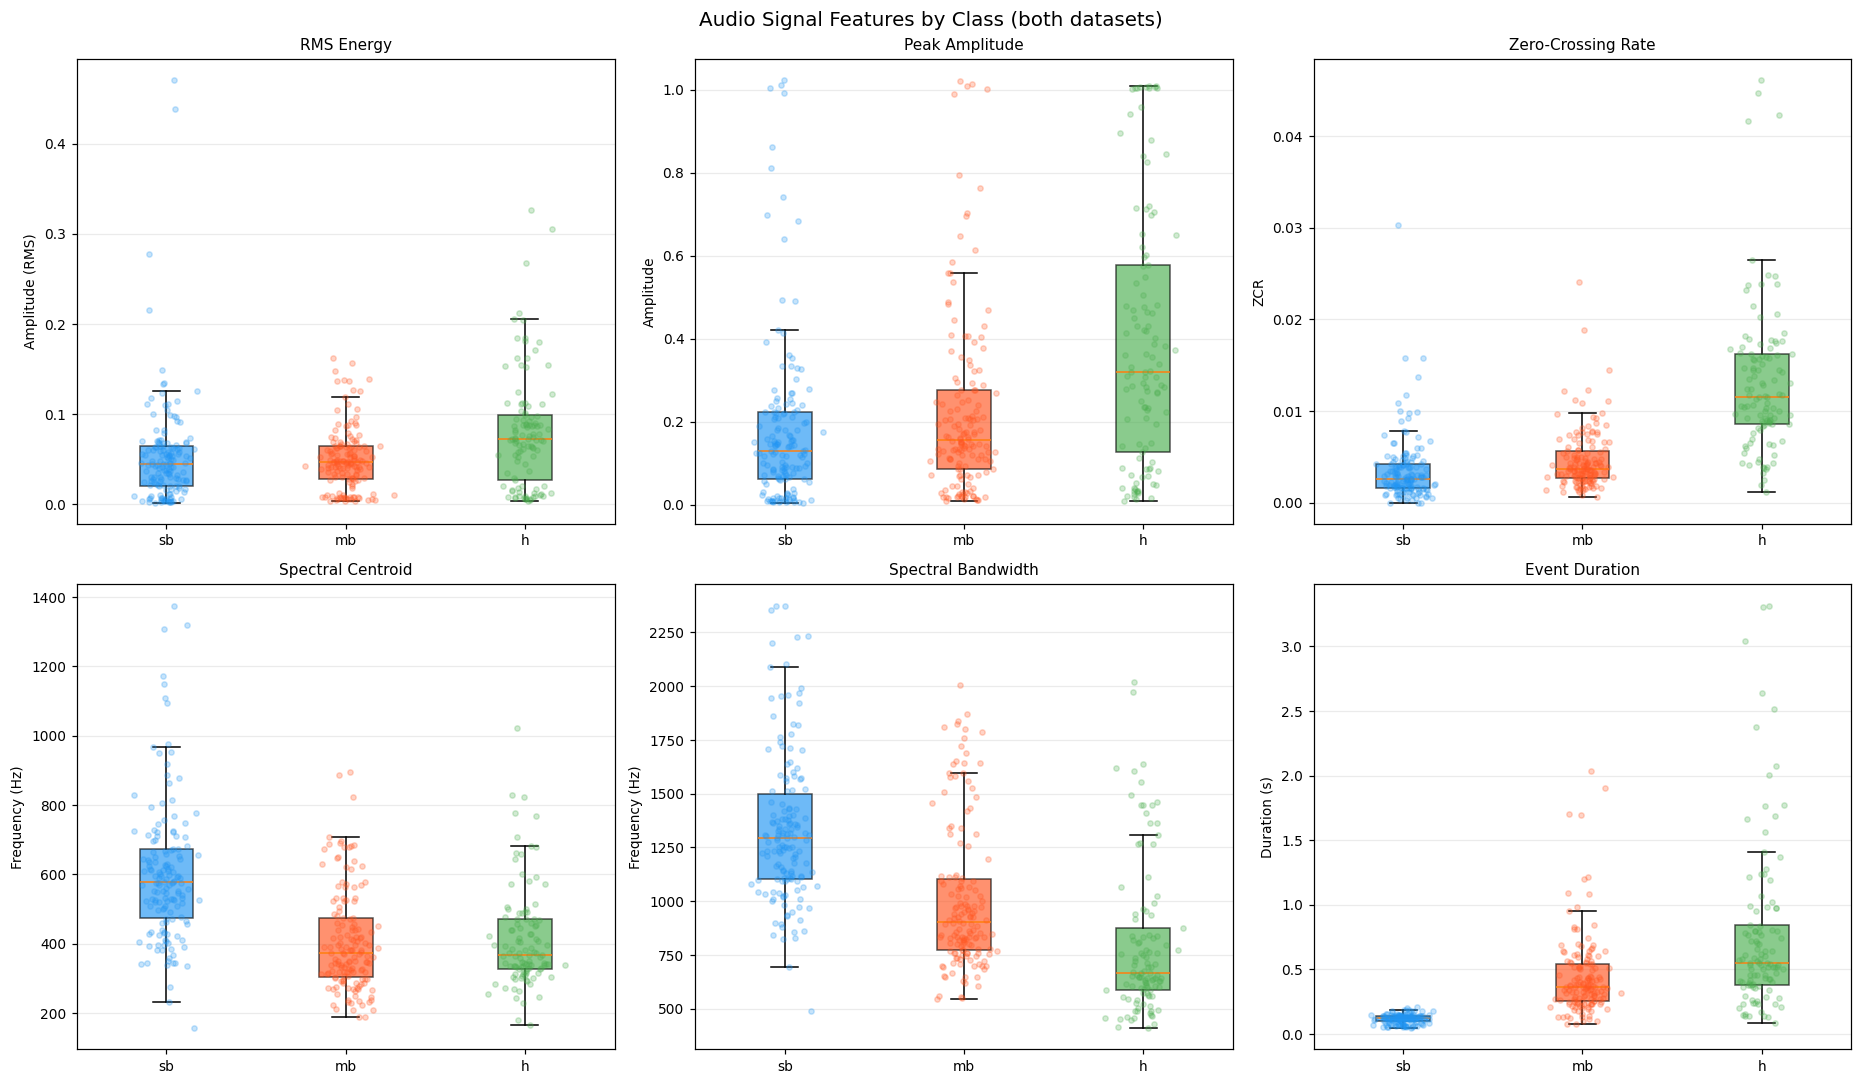

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Audio Signal Features by Class (both datasets)', fontsize=13)

features_list = [
    ('rms',                'RMS Energy',         'Amplitude (RMS)'),
    ('peak',               'Peak Amplitude',      'Amplitude'),
    ('zcr',                'Zero-Crossing Rate',  'ZCR'),
    ('spectral_centroid',  'Spectral Centroid',   'Frequency (Hz)'),
    ('spectral_bandwidth', 'Spectral Bandwidth',  'Frequency (Hz)'),
    ('duration',           'Event Duration',      'Duration (s)'),
]

for ax, (feat, title, ylabel) in zip(axes.flat, features_list):
    data   = [audio_df[audio_df['label']==l][feat].values for l in ALL_LABELS]
    colors = [CLASS_COLORS[l] for l in ALL_LABELS]
    bp = ax.boxplot(data, labels=ALL_LABELS, patch_artist=True, showfliers=False)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.65)
    for i, (d, c) in enumerate(zip(data, colors), start=1):
        jitter = np.random.normal(0, 0.07, len(d))
        ax.scatter(i + jitter, d, color=c, alpha=0.25, s=12, zorder=3)
    ax.set_title(title, fontsize=10); ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_audio_features.png'), dpi=120, bbox_inches='tight')
plt.show()

### 📋 Full Corrected Conclusion 
*(You can copy/paste this updated version into your report)*

The signal features reveal **distinct acoustic fingerprints** for each class:

| Feature | SB | MB | H | Interpretation |
|---|---|---|---|---|
| RMS energy | 0.054 | 0.050 | **0.080** | `h` is the loudest — sustained energy |
| Peak amplitude | 0.184 | 0.224 | **0.393** | `h` clips are much more energetic overall |
| Zero-crossing rate | 0.0035 | 0.0046 | **0.0131** | `h` has much faster oscillation — tonal character |
| Spectral centroid | **602 Hz** | 406 Hz | 413 Hz | `sb` energy concentrates at much higher frequencies |
| Spectral bandwidth | **1339 Hz** | 1008 Hz | 803 Hz | `sb` is broadband; `h` is more narrow/tonal |

**SB (Single Burst):** High spectral centroid (602 Hz) + high bandwidth (1339 Hz) = broadband, high-frequency transient clicks. These are impulse-like sounds, which is why they appear as brief vertical spikes in the spectrogram.

**MB (Multiple Burst):** Features the lowest average spectral centroid (406 Hz) and lowest mean RMS (0.050). Acoustically, this suggests that `mb` events are not simply repeated high-frequency `sb` clicks; they are deeper, lower-frequency "bubbling" or "gurgling" sequences. The lower mean RMS is likely due to the quiet gaps between the rapid, repeated bursts pulling the overall average energy down.

**H (Harmonic):** Highest RMS (0.080), peak (0.393), and ZCR (0.013). The elevated ZCR is the clearest sign of periodicity — the signal crosses zero more frequently because it is a tonal, oscillating wave. The lower bandwidth (803 Hz) confirms energy concentrates in a narrower frequency band.

**ML implication:** These feature differences are large enough for a CNN to effectively learn and discriminate between classes. However, the extreme class imbalance in the broader dataset (e.g., a 10:1 ratio between `sb` and `h` events) means the model will be biased toward the high-frequency broadband profile of `sb`. To counteract this, the loss function **must** be class-weighted during training.

## 8 · Mel Spectrograms — Representative Events per Class

For each class we pick the event closest to **min / p25 / median / mean / p75 / max** duration.
We show a **separate grid for each recording** so acoustic differences between datasets are visible.

Dashed lines mark event boundaries (50ms padding each side). Fixed dB scale across all panels.

In [10]:
print('Loading audio for spectrogram analysis (may take ~30 s)...')
audio = {}
for name, f in FILES.items():
    y, _ = librosa.load(str(f['wav']), sr=SR)
    audio[name] = y
    print(f'  {name}: {len(y)/SR:.1f} s loaded')
print('Done.')

def event_mel(row, pad=VIZ_PAD):
    y_full = audio[row['recording']]
    total  = len(y_full) / SR
    s = max(0, row['start'] - pad)
    e = min(total, row['end']  + pad)
    seg = y_full[int(s*SR): int(e*SR)]
    mel = librosa.feature.melspectrogram(
        y=seg, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX)
    return librosa.power_to_db(mel, ref=np.max)

def pick_representatives(df_class):
    dur = df_class['duration']
    targets = {'min': dur.min(), 'p25': dur.quantile(0.25), 'median': dur.median(),
               'mean': dur.mean(), 'p75': dur.quantile(0.75), 'max': dur.max()}
    return {name: df_class.loc[(dur - target).abs().idxmin()]
            for name, target in targets.items()}

print('Helpers ready.')

Loading audio for spectrogram analysis (may take ~30 s)...
  23M74M: 300.6 s loaded
  AS_1: 2212.4 s loaded
Done.
Helpers ready.


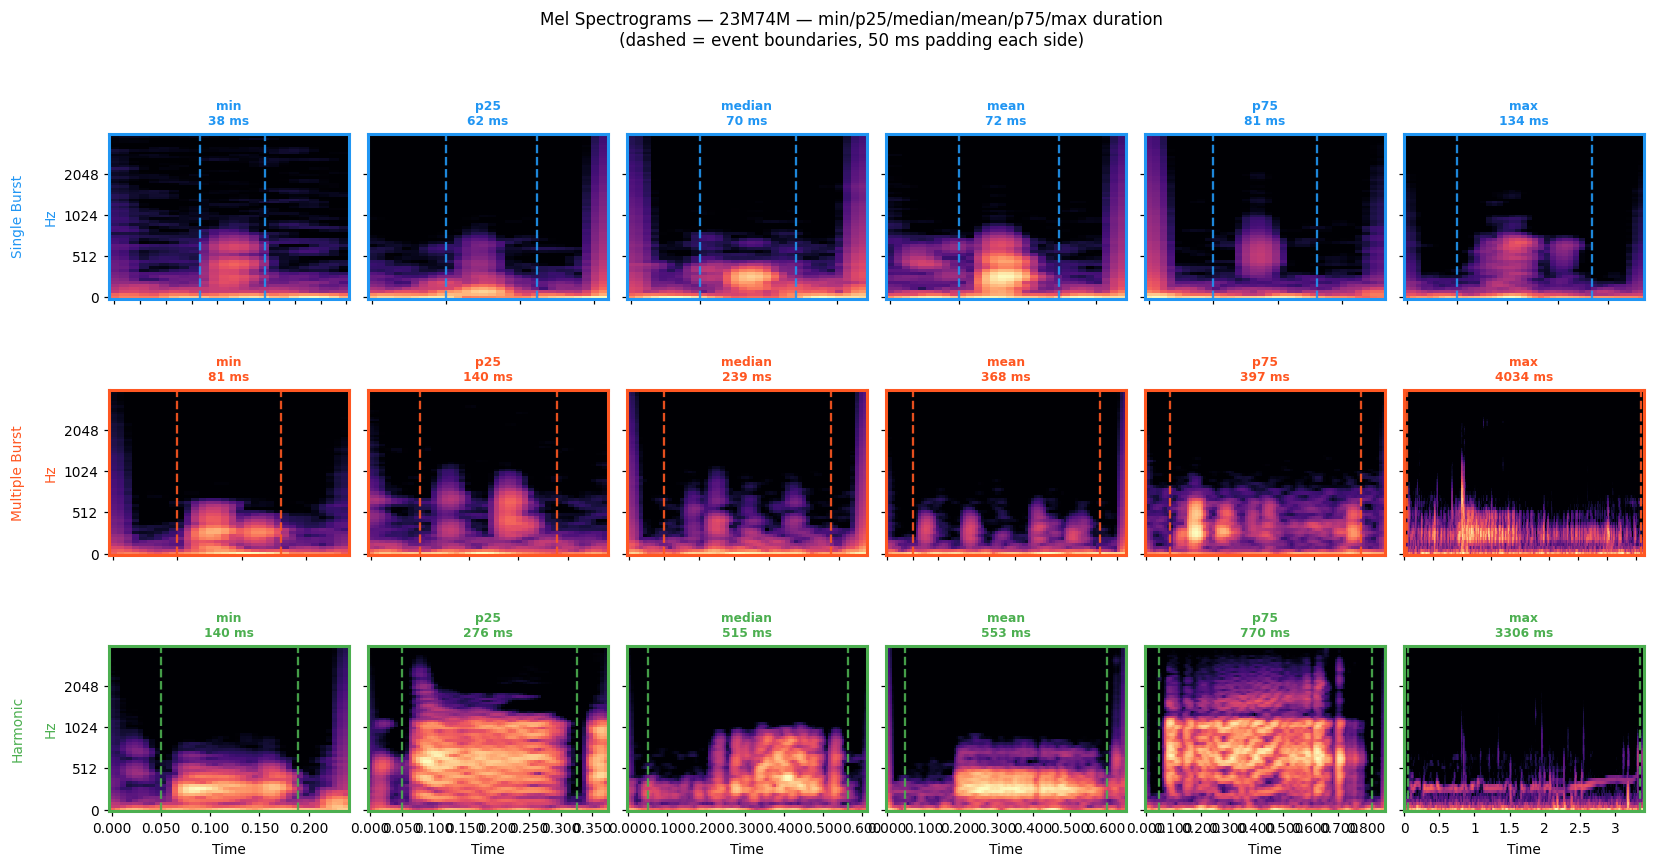

Grid saved for 23M74M


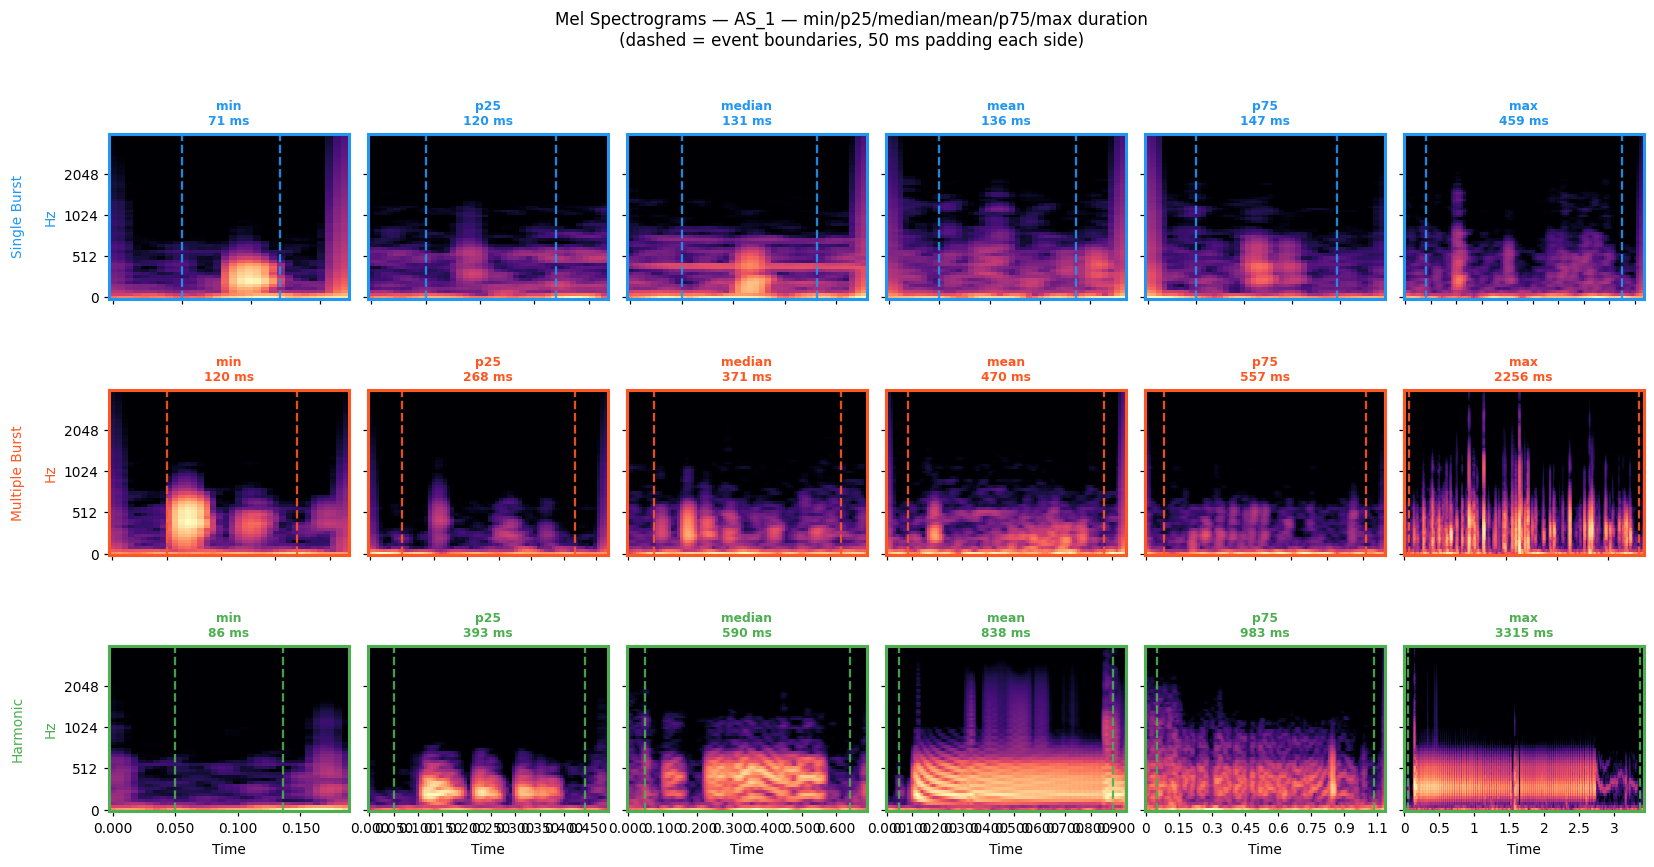

Grid saved for AS_1


In [11]:
COLS     = ['min', 'p25', 'median', 'mean', 'p75', 'max']
DATASETS = ['23M74M', 'AS_1']
VMIN, VMAX = -60, 0

for ds in DATASETS:
    df_ds = bowel_df[bowel_df['recording'] == ds]
    fig, axes = plt.subplots(3, 6, figsize=(18, 8),
                              gridspec_kw={'hspace': 0.55, 'wspace': 0.08})
    fig.suptitle(f'Mel Spectrograms — {ds} — min/p25/median/mean/p75/max duration\n'
                 '(dashed = event boundaries, 50 ms padding each side)',
                 fontsize=11, y=1.02)

    for r, cls in enumerate(ALL_LABELS):
        df_cls = df_ds[df_ds['label'] == cls]
        if len(df_cls) == 0:
            for c in range(6): axes[r][c].axis('off')
            continue
        reps  = pick_representatives(df_cls)
        color = CLASS_COLORS[cls]

        for c, col_name in enumerate(COLS):
            ax  = axes[r][c]
            row = reps[col_name]
            S_db = event_mel(row)

            librosa.display.specshow(S_db, sr=SR, hop_length=HOP_LENGTH,
                x_axis='time', y_axis='mel', fmax=FMAX,
                ax=ax, cmap='magma', vmin=VMIN, vmax=VMAX)

            ax.axvline(VIZ_PAD,                   color=color, lw=1.5, ls='--', alpha=0.9)
            ax.axvline(VIZ_PAD + row['duration'],  color=color, lw=1.5, ls='--', alpha=0.9)
            ax.set_facecolor('#111')
            ax.set_title(f"{col_name}\n{row['duration']*1000:.0f} ms",
                         fontsize=8, color=color, fontweight='bold')

            if c > 0:
                ax.set_ylabel('')
                ax.set_yticklabels([])
            if r < 2:
                ax.set_xlabel('')
                ax.set_xticklabels([])
            for spine in ax.spines.values():
                spine.set_edgecolor(color); spine.set_linewidth(2)

        axes[r][0].set_ylabel(f"{CLASS_NAMES[cls]}\n\nHz", fontsize=9, color=color)

    plt.savefig(str(OUT_DIR / f'exp00_mel_grid_{ds}.png'), bbox_inches='tight', dpi=120)
    plt.show()
    print(f'Grid saved for {ds}')

### 📋 Conclusion: Mel Spectrogram Visual Analysis 

The Mel Spectrogram visualizations reveal **distinct structural and frequency-based fingerprints** for each class, as well as crucial boundaries for acoustic energy:

| Visual Feature | SB | MB | H | Interpretation |
|---|---|---|---|---|
| **Morphology** | Vertical blob | Clustered vertical blobs | Horizontal stripes | `sb` and `mb` are impulsive (broadband bursts); `h` is tonal (resonating frequency). |
| **Energy Band** | < 1024 Hz | < 1024 Hz | < 1024 Hz (stacked) | Bowel acoustic energy overwhelmingly dominates the lower frequencies. |
| **Temporal Shape** | Very brief | Highly variable; up to 4s of dense noise | Sustained | `mb` outliers act as continuous chaotic walls of sound; `h` sustains clearly over time. |
| **Texture** | Amorphous / Solid | Gapped / Chaotic | Parallel lines | `h` features distinct fundamental frequencies and overtones. |

**SB (Single Burst):** Appears as sudden, vertically oriented amorphous "blobs." This visual shape confirms they are broad-spectrum, sudden bursts of energy (impulses) without a defined pitch, naturally bounded within a fraction of a second.

**MB (Multiple Burst):** Shares the exact same impulsive, broad-spectrum spectral "texture" as SB, but appears sequentially. While typical events look like a rapid sequence of vertical blobs, the extreme outliers (up to 4.0 seconds) devolve into a chaotic, unbroken wall of broad noise representing continuous bubbling/gurgling. 

**H (Harmonic):** Radically different from the other two classes. It is characterized by highly distinct **horizontal striations (stripes)**, which are the visual signature of a fundamental frequency vibrating with clear overtones (like a groan or hum). Patient-specific variations are also visible here: Patient `AS_1` produces incredibly sharp, almost synthetic-looking harmonic stacks, while `23M74M` produces broader, "fuzzier" harmonics.

**ML Implications:** 
1. **Model Architecture:** Because `SB` and `MB` share identical visual textures, a CNN or Vision Transformer will have to rely almost entirely on the x-axis (temporal length) to tell them apart, whereas `H` will be easily separated via its horizontal shape.
2. **Dimensionality Reduction:** Because nearly all significant acoustic energy sits below 1024 Hz (and mostly below 512 Hz), high-frequency spectrogram rows are functionally dead space. Aggressively **low-pass filtering** the audio (e.g., cutoff at 1500 Hz) or downsampling the raw wav files will drastically reduce memory footprint and compute time without losing biological information.
3. **Data Leakage:** The visible patient-specific signatures (e.g., the exact spacing of `H` striations) prove that models could easily memorize individual patient bowels. A strict **patient-level data split** is mandatory to ensure genuine generalization.

## 9 · Mean Mel Spectrum per Class — Both Datasets

Average mel energy per frequency bin across all events of each class. Reveals the **frequency fingerprint** and whether it differs between recordings.

Computing mean mel spectra (both datasets, all events)...
  23M74M/sb: 255 events
  23M74M/mb: 230 events
  23M74M/h: 29 events
  AS_1/sb: 858 events
  AS_1/mb: 774 events
  AS_1/h: 80 events


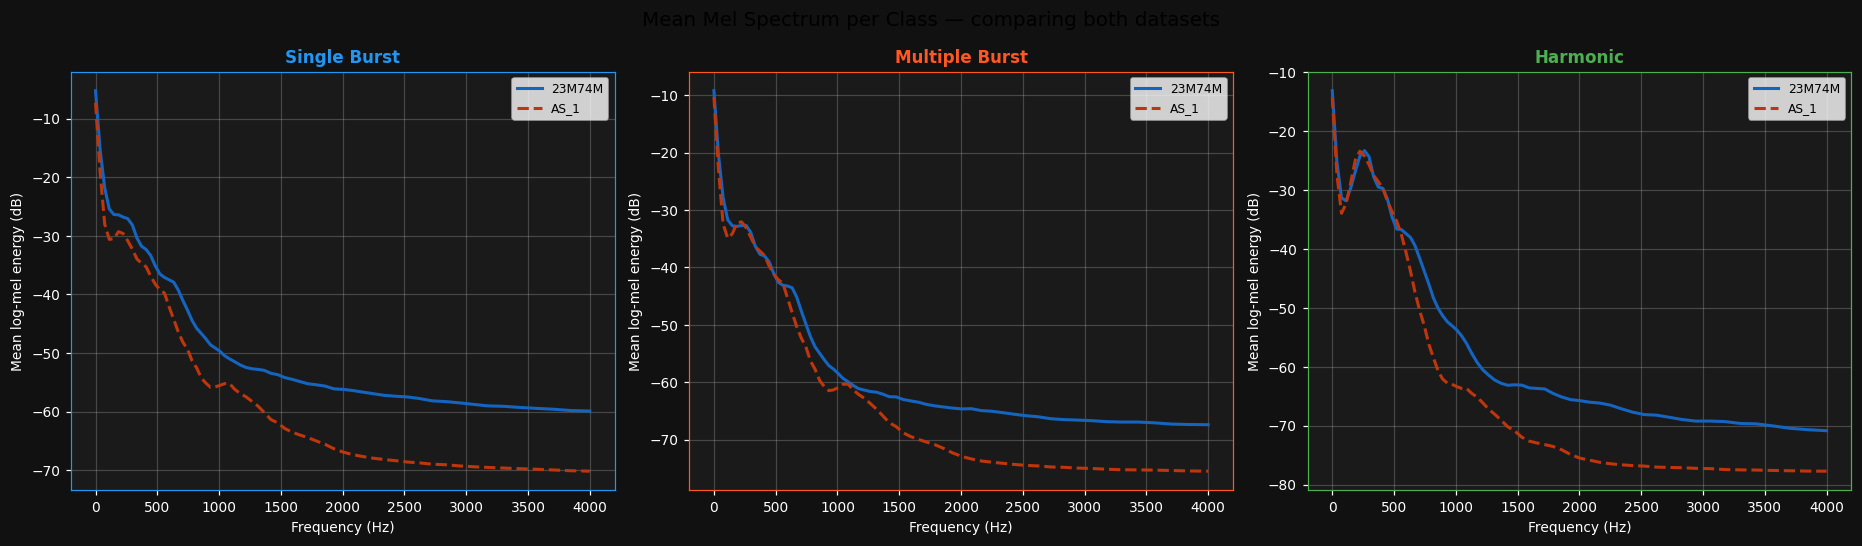

In [12]:
print('Computing mean mel spectra (both datasets, all events)...')
mel_freqs    = librosa.mel_frequencies(n_mels=N_MELS, fmax=FMAX)
mean_spectra = {}   # key: (cls, recording)

for ds in DATASETS:
    for cls in ALL_LABELS:
        df_sub = bowel_df[(bowel_df['recording']==ds) & (bowel_df['label']==cls)]
        if len(df_sub) == 0:
            continue
        spectra = []
        for _, row in df_sub.iterrows():
            S_db = event_mel(row, pad=0.0)
            spectra.append(S_db.mean(axis=1))
        mean_spectra[(cls, ds)] = np.array(spectra).mean(axis=0)
        print(f'  {ds}/{cls}: {len(spectra)} events')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Mean Mel Spectrum per Class — comparing both datasets', fontsize=13)

for ax, cls in zip(axes, ALL_LABELS):
    for ds, ls in [('23M74M', '-'), ('AS_1', '--')]:
        key = (cls, ds)
        if key in mean_spectra:
            ax.plot(mel_freqs, mean_spectra[key],
                    color=REC_COLORS[ds], lw=2, ls=ls, label=ds)
    ax.set_title(CLASS_NAMES[cls], color=CLASS_COLORS[cls], fontweight='bold', fontsize=11)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Mean log-mel energy (dB)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_facecolor('#1a1a1a')
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
    ax.title.set_color(CLASS_COLORS[cls]); ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor(CLASS_COLORS[cls])

fig.patch.set_facecolor('#111')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_mean_spectrum_per_dataset.png'), bbox_inches='tight', dpi=120, facecolor='#111')
plt.show()

### 📋 Conclusion: Mean Spectral Energy Distribution

The Mean Mel Spectrum plots provide a quantitative cross-section of the acoustic energy across frequencies. By plotting the mean log-mel energy (dB) against frequency (Hz), we validate the visual observations from the spectrograms and expose dataset-specific hardware/environmental artifacts.

| Acoustic Feature | Observation across all classes | Class-Specific Differences |
|---|---|---|
| **Energy Concentration** | **Extreme low-frequency dominance.** Energy peaks near 0 Hz (~ -10 dB) and falls off a cliff, dropping by ~40-50 dB by 1500 Hz. | `SB` and `MB` show smooth, exponential decays. `H` shows distinct "bumps" in the decay curve (e.g., at ~250 Hz and ~500 Hz). |
| **Noise Floor** | Beyond 2000 Hz, the curves flatten out, representing background room noise or microphone hiss rather than biological signals. | The noise floor for `MB` and `H` drops slightly lower (-70 to -80 dB) compared to the higher broadband noise floor of `SB`. |
| **Dataset Variance** | **23M74M** consistently maintains higher energy in the upper frequencies (>1000 Hz) compared to **AS_1**. | This gap is most pronounced in `SB` and `H`, where the `AS_1` curve falls much deeper into the noise floor than `23M74M`. |

**1. The Harmonic "Bumps" vs. Impulsive Smoothness:** 
The mean spectral curves mathematically confirm the structural differences between classes. `SB` and `MB` are broadband transients, resulting in a smooth, continuous roll-off of energy. In contrast, the Harmonic (`H`) plots feature distinct, periodic peaks in the low-frequency range. These peaks correspond directly to the fundamental frequencies and resonating overtones (the "horizontal stripes" seen in the spectrograms). 

**2. Absolute Low-Frequency Dominance:**
A 40-50 dB drop from 0 Hz to 1500 Hz means the acoustic power of the signal is tens of thousands of times weaker at 1500 Hz than at its peak. The biological information of bowel motility is almost entirely contained below the 1000–1500 Hz threshold.

**3. Divergent Environmental Backgrounds:**
The divergence between the solid blue line (`23M74M`) and dashed orange line (`AS_1`) in the high-frequency ranges (>1500 Hz) does not represent different bowel sounds; it represents different background noise profiles. `23M74M` has a higher, louder ambient noise floor. 

**ML Implications:**
1. **Aggressive Cropping/Filtering is Mathematically Justified:** we can safely apply a **Low-Pass Filter (cutoff at 1000 - 1500 Hz)** or configure your Mel Spectrogram generator to use an `fmax` of 1500. Processing frequencies up to 4000 Hz is a waste of computational resources and memory, as it forces the model to process dead space.
2. **The "Clever Hans" Effect (Confounding Variable Risk):** Because the background noise floors differ significantly between datasets, a naive Neural Network might learn to predict the *patient/recording environment* based on the high-frequency hiss, rather than learning the actual bowel sounds. 
3. **Mandatory Augmentation:** To prevent the model from overfitting to the specific room acoustics of `23M74M` or `AS_1`, the training pipeline should include **background noise augmentation** (injecting random Gaussian/pink noise) to normalize the noise floors across the training data.

## 10 · Spectral Centroid Distribution — Both Datasets

Spectral centroid per event, split by class and by recording. Differences reveal frequency domain domain-shift between patients.

Computing spectral centroids (both datasets)...


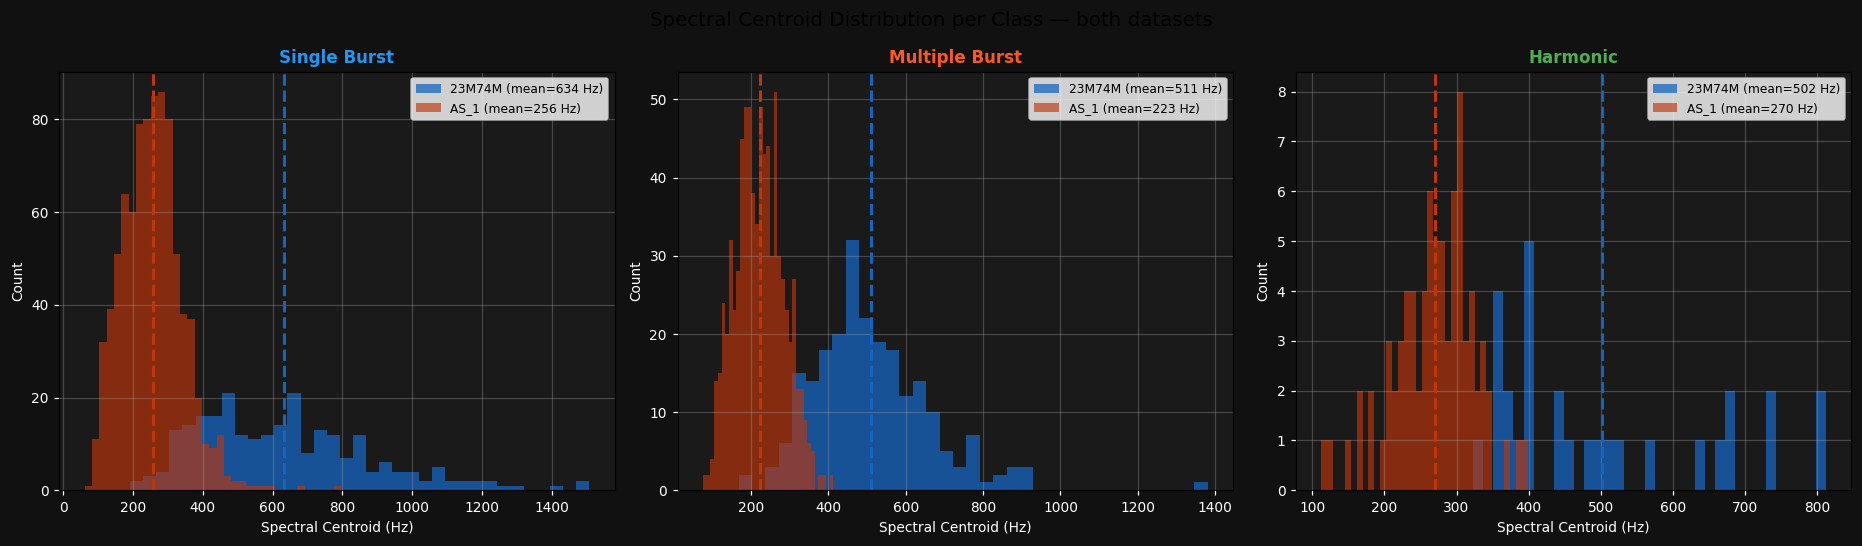


── Spectral centroid means by class and dataset ──
       23M74M_mean_hz  23M74M_std_hz  AS_1_mean_hz  AS_1_std_hz
class                                                          
sb              634.0          251.0         256.0         87.0
mb              511.0          154.0         223.0         61.0
h               502.0          147.0         270.0         55.0


In [13]:
print('Computing spectral centroids (both datasets)...')
centroids = {(cls, ds): [] for cls in ALL_LABELS for ds in DATASETS}

for ds in DATASETS:
    for cls in ALL_LABELS:
        df_sub = bowel_df[(bowel_df['recording']==ds) & (bowel_df['label']==cls)]
        for _, row in df_sub.iterrows():
            y_full = audio[row['recording']]
            s = max(0, int(row['start']*SR))
            e = min(len(y_full), int(row['end']*SR))
            seg = y_full[s:e]
            if len(seg) < N_FFT: continue
            c = librosa.feature.spectral_centroid(y=seg, sr=SR, n_fft=N_FFT,
                                                   hop_length=HOP_LENGTH)[0]
            centroids[(cls, ds)].append(float(np.median(c)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Spectral Centroid Distribution per Class — both datasets', fontsize=13)

for ax, cls in zip(axes, ALL_LABELS):
    for ds, alpha in [('23M74M', 0.75), ('AS_1', 0.65)]:
        vals = centroids[(cls, ds)]
        if not vals: continue
        ax.hist(vals, bins=35, alpha=alpha, color=REC_COLORS[ds],
                label=f'{ds} (mean={np.mean(vals):.0f} Hz)', edgecolor='none')
        ax.axvline(np.mean(vals), color=REC_COLORS[ds], lw=2, ls='--')
    ax.set_title(CLASS_NAMES[cls], color=CLASS_COLORS[cls], fontweight='bold', fontsize=11)
    ax.set_xlabel('Spectral Centroid (Hz)'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_facecolor('#1a1a1a')
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
    ax.title.set_color(CLASS_COLORS[cls]); ax.tick_params(colors='white')

fig.patch.set_facecolor('#111')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_centroid_per_dataset.png'), bbox_inches='tight', dpi=120, facecolor='#111')
plt.show()

# Summary table
print('\n── Spectral centroid means by class and dataset ──')
rows = []
for cls in ALL_LABELS:
    row = {'class': cls}
    for ds in DATASETS:
        vals = centroids[(cls, ds)]
        row[f'{ds}_mean_hz'] = round(np.mean(vals), 0) if vals else None
        row[f'{ds}_std_hz']  = round(np.std(vals), 0)  if vals else None
    rows.append(row)
print(pd.DataFrame(rows).set_index('class').to_string())

### 📋 Conclusion: Spectral Centroid Distribution

The Spectral Centroid analysis reveals a **massive acoustic domain gap** between the two recordings. While the structural shapes of the sounds (morphology) remain consistent across patients, the absolute frequencies they occupy do not.

| Class | 23M74M (Mean ± Std) | AS_1 (Mean ± Std) | Observation |
|---|---|---|---|
| **SB** | 634 Hz ± 251 | 256 Hz ± 87 | Massive domain gap (~380 Hz shift). 23M74M's distribution is much wider. |
| **MB** | 511 Hz ± 154 | 223 Hz ± 61 | ~290 Hz shift. In both patients, `MB` is lower-pitched than `SB`. |
| **H** | 502 Hz ± 147 | 270 Hz ± 55 | ~230 Hz shift. The tonal frequencies for AS_1 are remarkably concentrated. |

**1. Severe Dataset Shift (The Domain Gap):** 
Across every single class, the spectral "center of mass" for patient `23M74M` is roughly **double** that of patient `AS_1`. This is clearly visible in the histograms, where the blue distributions (23M74M) are shifted entirely to the right with very little overlap with the orange distributions (AS_1). 

**2. Intact Class Relationships:** 
Despite the absolute frequency shift between patients, the *relative* relationship between classes holds true: inside *both* recordings, `SB` events contain the highest frequencies (broadband clicks), while `MB` and `H` are deeper and lower-pitched.

**🔥 Key ML Implications:**
1. **Model Generalization Failure (Covariate Shift):** If an ML model is trained on `AS_1`, it will learn that bowel sounds live around 220–270 Hz. If blindly tested on `23M74M`, it will likely fail to detect events at 500–600 Hz. A simple pooled dataset will hide this flaw.
2. **Mandatory Normalization:** You must utilize techniques that force the model to learn the *relative structural shapes* of the spectrograms, rather than their absolute frequencies. Techniques like **Per-Channel Energy Normalization (PCEN)** or standardizing the Mel Spectrograms (Z-score normalization *per recording*) are strictly required. 
3. **Pitch Augmentation:** During training, dynamically applying **Pitch Shifting** augmentations (e.g., ± 200 Hz) will artificially bridge the gap between these two distributions, making the model robust to varying patient resonance.

## 11 · Listen — Audio Clips per Class

Exports **min / median / max** duration events from **each dataset** as `.wav` files. 100ms padding each side.

In [14]:
LISTEN_REPS = ['min', 'median', 'max']

def extract_listen_clip(row, pad=LISTEN_PAD):
    y_full = audio[row['recording']]
    total  = len(y_full) / SR
    s = max(0.0, row['start'] - pad)
    e = min(total, row['end']   + pad)
    seg = y_full[int(s*SR): int(e*SR)]
    seg = seg / (np.abs(seg).max() + 1e-9)
    return seg

for ds in DATASETS:
    print(f'\n{"="*55}')
    print(f'  DATASET: {ds}')
    print(f'{"="*55}')
    df_ds = bowel_df[bowel_df['recording'] == ds]

    for cls in ALL_LABELS:
        df_cls = df_ds[df_ds['label'] == cls]
        if len(df_cls) == 0: continue
        reps = pick_representatives(df_cls)
        print(f'\n  ── {CLASS_NAMES[cls]} ({cls}) ──')

        for rep_name in LISTEN_REPS:
            row    = reps[rep_name]
            seg    = extract_listen_clip(row)
            dur_ms = int(row['duration'] * 1000)
            fname  = f'{ds}_{cls}_{rep_name}_{dur_ms}ms.wav'
            fpath  = AUDIO_OUT / fname
            wavfile.write(str(fpath), SR, (seg * 32767).astype('int16'))

            ipy_display(ipd.Markdown(
                f'**{ds} · {CLASS_NAMES[cls]} · {rep_name}** — {dur_ms} ms  '
                f'(t={row["start"]:.2f}–{row["end"]:.2f}s)'))
            ipy_display(Audio(data=seg, rate=SR))

print(f'\nAll clips saved to: {AUDIO_OUT}')


  DATASET: 23M74M

  ── Single Burst (sb) ──


**23M74M · Single Burst · min** — 37 ms  (t=140.56–140.60s)

**23M74M · Single Burst · median** — 69 ms  (t=145.80–145.87s)

**23M74M · Single Burst · max** — 134 ms  (t=36.50–36.63s)


  ── Multiple Burst (mb) ──


...


  ── Harmonic (h) ──


**AS_1 · Harmonic · min** — 86 ms  (t=507.99–508.08s)

**AS_1 · Harmonic · median** — 589 ms  (t=240.43–241.02s)

**AS_1 · Harmonic · max** — 3315 ms  (t=962.53–965.85s)


All clips saved to: audio_clips


## 12 · Cross-Dataset Acoustic Comparison

Side-by-side summary of all acoustic differences between the two recordings. This is the domain-shift characterisation that explains generalisation gaps in model results.

Compiling cross-dataset comparison table...

── Single Burst (sb) ──
         n_events  dur_median_ms  dur_p10_ms  dur_p90_ms  rms_mean  zcr_mean  centroid_hz
dataset                                                                                  
23M74M        255           69.8        53.7        91.2    0.0072   0.00406        634.0
AS_1          858          131.1       109.2       169.3    0.0666   0.00340        256.0

── Multiple Burst (mb) ──
         n_events  dur_median_ms  dur_p10_ms  dur_p90_ms  rms_mean  zcr_mean  centroid_hz
dataset                                                                                  
23M74M        230          238.9       117.8       781.3    0.0086   0.00641        511.0
AS_1          774          371.4       218.5       835.7    0.0613   0.00409        223.0

── Harmonic (h) ──
         n_events  dur_median_ms  dur_p10_ms  dur_p90_ms  rms_mean  zcr_mean  centroid_hz
dataset                                                                   

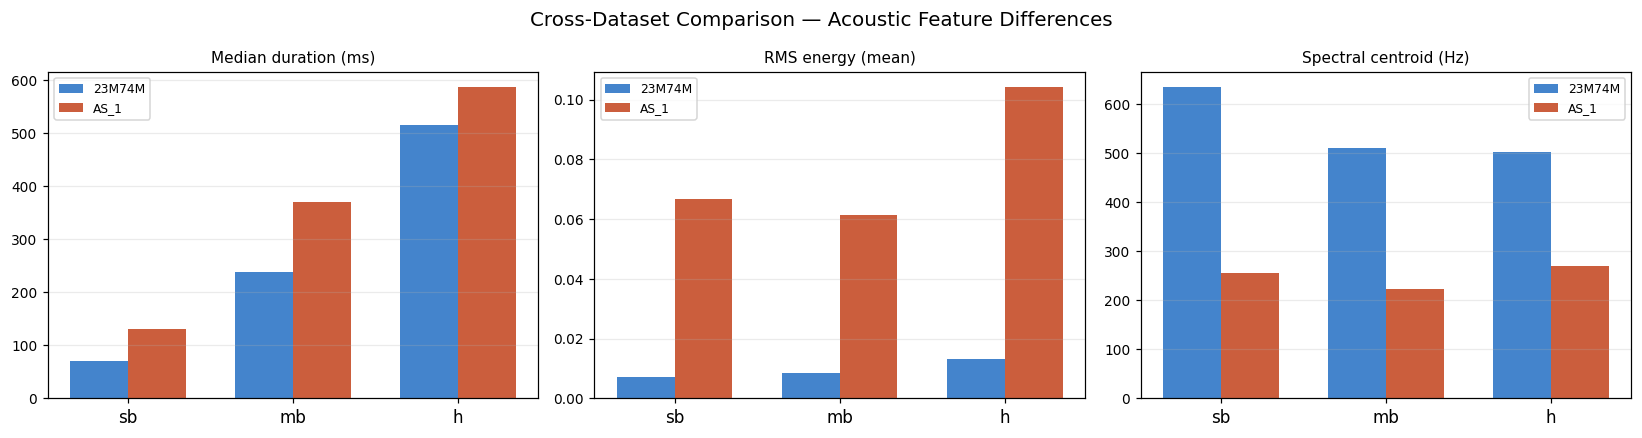

In [15]:
print('Compiling cross-dataset comparison table...')

rows = []
for cls in ALL_LABELS:
    for ds in DATASETS:
        sub     = bowel_df[(bowel_df['recording']==ds) & (bowel_df['label']==cls)]
        a_sub   = audio_df[(audio_df['recording']==ds) & (audio_df['label']==cls)]
        c_vals  = centroids[(cls, ds)]
        rows.append({
            'class': cls, 'dataset': ds,
            'n_events':   len(sub),
            'dur_median_ms': round(sub['duration'].median()*1000, 1),
            'dur_p10_ms':    round(np.percentile(sub['duration'], 10)*1000, 1),
            'dur_p90_ms':    round(np.percentile(sub['duration'], 90)*1000, 1),
            'rms_mean':      round(a_sub['rms'].mean(), 4) if len(a_sub) else None,
            'zcr_mean':      round(a_sub['zcr'].mean(), 5) if len(a_sub) else None,
            'centroid_hz':   round(np.mean(c_vals), 0) if c_vals else None,
        })

cmp_df = pd.DataFrame(rows)
for cls in ALL_LABELS:
    print(f'\n── {CLASS_NAMES[cls]} ({cls}) ──')
    sub = cmp_df[cmp_df['class']==cls].set_index('dataset')
    print(sub[['n_events','dur_median_ms','dur_p10_ms','dur_p90_ms',
               'rms_mean','zcr_mean','centroid_hz']].to_string())

# Visual comparison heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cross-Dataset Comparison — Acoustic Feature Differences', fontsize=13)

feat_pairs = [
    ('dur_median_ms', 'Median duration (ms)'),
    ('rms_mean',      'RMS energy (mean)'),
    ('centroid_hz',   'Spectral centroid (Hz)'),
]

for ax, (feat, title) in zip(axes, feat_pairs):
    x   = np.arange(len(ALL_LABELS))
    w   = 0.35
    for i, (ds, offset) in enumerate([('23M74M', -w/2), ('AS_1', w/2)]):
        vals = [cmp_df[(cmp_df['class']==cls)&(cmp_df['dataset']==ds)][feat].values[0]
                for cls in ALL_LABELS]
        ax.bar(x + offset, vals, w, label=ds, color=REC_COLORS[ds], alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(ALL_LABELS, fontsize=11)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'exp00_cross_dataset_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

### 📋 Conclusion: Cross-Dataset Acoustic Comparison

The side-by-side analysis reveals a **systemic and massive domain shift** across multiple acoustic dimensions (duration, volume, and pitch). While absolute values differ drastically between the two patients, the relative structural signatures of the sounds remain strictly consistent.

| Acoustic Feature | 23M74M Profile | AS_1 Profile | Observation |
|---|---|---|---|
| **Median Duration (SB)** | 69.8 ms | 131.1 ms | `AS_1` burst events are nearly **twice as long**. |
| **RMS Energy (Volume)** | Very Low (~0.008 mean) | Very High (~0.077 mean) | `AS_1` is universally **7–9x louder** across all classes, indicating different recording hardware/gain. |
| **Spectral Centroid** | High (~500–634 Hz) | Low (~220–270 Hz) | Confirms the severe pitch covariate shift (~300 Hz gap). |

**1. Absolute Acoustic Disparity:** 
The two recordings exist in entirely different acoustic spaces. `AS_1` is fundamentally louder, lower-pitched, and features longer event durations. This proves that bowel motility sounds are highly patient- and hardware-dependent.

**2. Intact Relative Relationships (The Saving Grace):** 
Despite the drastic absolute shifts, the *relative* rules hold perfectly within both datasets: `SB` is always the shortest and highest-pitched (transient click), while `H` is always the longest and most energetic (sustained tone). 

**🔥 Key ML Implications:**
1. **Patient-Level Splitting is Mandatory:** A random 80/20 train/test split will cause catastrophic data leakage. A model could easily "cheat" by learning to classify based on the patient's baseline volume or background pitch. Evaluation must be done on unseen patients (Leave-One-Subject-Out CV).
2. **Aggressive Normalization:** Because of the 9x volume gap, you cannot feed raw audio arrays into the model. **Amplitude normalization** (e.g., Z-score scaling the Mel Spectrograms per-recording or PCEN) is absolutely required to equalize the loudness gap.
3. **Temporal & Pitch Augmentation:** To make a model robust to these patient variances, your training pipeline must include **Time Stretching** (to account for the 70ms vs 130ms duration gap) and **Pitch Shifting** (to bridge the 300 Hz centroid gap).


## 13 Observations & General Conclusion — Bowel Sound Data Analysis

### 1. Dataset Overview and Quality

The dataset comprises two recordings from distinct patients: **23M74M** (5 min, 514 bowel events, ~103 ev/min) and **AS_1** (37 min, 1712 bowel events, ~46 ev/min). Both files required label standardisation before any analysis — AS_1 used `b` instead of `sb` for 857 events, and both had whitespace-corrupted labels. After cleaning, the combined dataset yields **2,226 annotated bowel sound events** across three classes: `sb` (50%), `mb` (45%), and `h` (5%). The severe imbalance of the harmonic class — only 109 events total — is the most critical labelling constraint and directly demands class-weighted loss functions in every training pipeline.

---

### 2. Acoustic Signatures per Class

The three bowel sound classes have measurably distinct acoustic identities that are consistent across both recordings:

**Single Burst (sb)** is a short, broadband, high-frequency transient. Its spectral centroid (~600 Hz in 23M74M, ~256 Hz in AS_1) is the highest of all three classes, its bandwidth is the widest (1339 Hz), and it appears as a vertical amorphous blob in the mel spectrogram. It is an impulse — not a tone.

**Multiple Burst (mb)** shares the same impulsive broadband texture as sb but is composed of repeated bursts in sequence. Its spectral centroid is the lowest (~400 Hz combined), its mean RMS the weakest, and its duration the most variable — ranging from 150ms up to 4 seconds. Short mb events and long sb events are visually and acoustically similar, making temporal length the primary discriminating feature between the two classes.

**Harmonic (h)** is structurally different from the other two. It produces clear horizontal striations in the spectrogram — the visual signature of a sustained tonal oscillation with overtones. Its zero-crossing rate (0.013) is three times higher than sb, confirming periodicity, and its peak amplitude (0.393) is twice that of the other classes. h is the easiest class to separate visually but the hardest to train on due to its scarcity.

---

### 3. Duration and the Frame Resolution Problem

Duration distributions reveal a fundamental processing constraint. `sb` has a median of **126ms** but a p10 of just **70ms** (23M74M patient specifically). At 20ms frame resolution, a SMOOTH_WIN of 5 frames (100ms) would kill a significant fraction of the shortest sb events before evaluation ever runs. This makes post-processing window size a direct bottleneck on recall for the smallest class. Per-class smoothing is the appropriate solution: `sb=3 frames`, `mb=5 frames`, `h=7 frames`.

---

### 4. The Domain Gap — The Central Challenge

The most consequential finding of the entire analysis is the **systematic acoustic domain shift between the two recordings**. This is not noise — it is a structural, multi-dimensional divergence:

| Dimension | 23M74M | AS_1 | Gap |
|-----------|--------|------|-----|
| sb duration (median) | 70ms | 131ms | **1.9×** |
| RMS energy (mean) | ~0.008 | ~0.077 | **~9×** |
| Spectral centroid (sb) | 634 Hz | 256 Hz | **~380 Hz** |
| Spectral centroid (mb) | 511 Hz | 223 Hz | **~290 Hz** |
| Spectral centroid (h) | 502 Hz | 270 Hz | **~230 Hz** |

Every single class in 23M74M resonates at roughly double the frequency of AS_1. The recordings also differ in absolute volume by a factor of nine, and in background noise profile — 23M74M has a louder high-frequency noise floor. Despite all of this, the **relative ordering between classes is preserved in both recordings**: sb is always the shortest and highest-pitched, h is always the most energetic and tonal, and mb always sits between them. This consistency is the "saving grace" that makes cross-patient generalisation possible in principle.

---

### 5. Implications for the Machine Learning Pipeline

These findings translate into a set of non-negotiable design decisions for any model trained on this data:

**Data splitting:** A random pooled split is invalid. The volume and frequency differences between patients are large enough for a model to identify the recording source from the signal alone, producing catastrophically inflated metrics. Patient-level splitting — training on AS_1, evaluating on 23M74M — is the only honest evaluation protocol.

**Normalisation:** Raw waveforms and un-normalised spectrograms must not be fed to the model directly. The 9× volume difference requires amplitude normalisation (Z-score per recording, or PCEN). The spectrogram fmax can safely be capped at 1000–1500 Hz — energy above this threshold is background noise, not biological signal — which directly reduces memory and compute cost.

**Augmentation:** To bridge the domain gap, training augmentation should include pitch shifting (±200 Hz) to cover the frequency distribution of both patients, and time stretching to cover the duration gap in sb (70ms vs 131ms). Background noise injection is also necessary to prevent models from overfitting to the specific acoustic environment of either recording.

**Loss function:** The 10:1 imbalance between sb and h requires focal loss or class-weighted cross-entropy. Without it, models will systematically ignore harmonic events and report inflated aggregate accuracy driven entirely by sb and mb performance.

**Evaluation metric:** Frame-level accuracy is misleading on this data due to class imbalance and the dominance of background frames. Event-level F1 at multiple IoU thresholds (0.3, 0.5, 0.8) with FAR/min for false alarm monitoring is the correct evaluation framework.

---

### 6. Summary

This dataset is small, imbalanced, and drawn from patients with fundamentally different acoustic profiles — making it genuinely difficult. The good news is that the three bowel sound classes have consistent relative signatures across patients, sufficient for a well-regularised model to learn. The path to a generalisable detector runs through strict patient-level evaluation, aggressive signal normalisation, and targeted augmentation to bridge the spectral and durational gaps between the two recordings. Any model that performs well only on AS_1 validation should not be considered solved until it demonstrates comparable performance on 23M74M as the held-out test set.